#Import Libraries

In [ ]:
# =============================
# Combined Imports: TensorFlow + PyTorch
# =============================

# General
import os
import time
import shutil
import pathlib
import itertools
import warnings
warnings.filterwarnings("ignore")

# Image handling
from PIL import Image
import cv2

# Math & Data
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt

# =============================
# TensorFlow / Keras
# =============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Activation,
    Dropout, BatchNormalization
)
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# =============================
# PyTorch
# =============================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader

# Colab (optional)
from google.colab import drive

print("✅ All TensorFlow + PyTorch modules loaded")


✅ All TensorFlow + PyTorch modules loaded


# Set GPU device

In [ ]:
# Check if CUDA is available
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("✅ GPU is available. Using GPU.")
else:
    device = torch.device("cpu")
    print("⚠️ GPU not available. Using CPU.")

✅ GPU is available. Using GPU.


#Mounting the google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define class names

In [ ]:
class_names = ["All_Benign","All_Early","All_Pre","All_Pro"]

# Loading dataset

In [ ]:
import os

# Set your dataset paths
TRAIN_ROOT = "/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Training"
VAL_ROOT   = "/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Validation"
TEST_ROOT  = "/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)"

# Allowed image extensions
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp'}

def count_images(directory):
    total = 0
    for root, _, files in os.walk(directory):
        for file in files:
            # Ignore hidden files (e.g., .DS_Store)
            if not file.startswith('.') and os.path.splitext(file)[1].lower() in image_extensions:
                total += 1
    return total

# Count images
train_count = count_images(TRAIN_ROOT)
val_count   = count_images(VAL_ROOT)
test_count  = count_images(TEST_ROOT)

print("📊 Dataset Image Counts")
print(f"✔ Train:       {train_count}")
print(f"✔ Validation:  {val_count}")
print(f"✔ Test:        {test_count}")


📊 Dataset Image Counts
✔ Train:       14000
✔ Validation:  3000
✔ Test:        3000


# Define data transformations and FL with 3 Clients

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.datasets as datasets
from torchvision import transforms
import numpy as np
from collections import defaultdict
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Define data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full training dataset
full_train_dataset = datasets.ImageFolder(root=TRAIN_ROOT, transform=transform)

# Number of clients
NUM_CLIENTS = 3

# Function for balanced split (non-IID)
def create_balanced_split(dataset, num_clients):
    class_indices = defaultdict(list)

    # ✅ Use dataset.samples directly (path, label) without loading images
    for idx, (path, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    # Shuffle class-wise
    for label in class_indices:
        random.shuffle(class_indices[label])

    # Split into clients
    client_datasets = [[] for _ in range(num_clients)]

    for label, indices in class_indices.items():
        num_samples_per_client = len(indices) // num_clients

        for i in range(num_clients):
            client_datasets[i].extend(indices[i * num_samples_per_client:(i + 1) * num_samples_per_client])

    return [Subset(dataset, indices) for indices in client_datasets]

# Create balanced splits
client_datasets = create_balanced_split(full_train_dataset, NUM_CLIENTS)

# Check if the datasets have been split correctly
for i, dataset in enumerate(client_datasets):
    print(f"Client {i+1} has {len(dataset)} samples.")

Client 1 has 4664 samples.
Client 2 has 4664 samples.
Client 3 has 4664 samples.


Non-IID Splitting

In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root=TRAIN_ROOT, transform=transform)
val_dataset   = datasets.ImageFolder(root=VAL_ROOT,   transform=transform)
test_dataset  = datasets.ImageFolder(root=TEST_ROOT,  transform=transform)

print("Number of images in Train:", len(train_dataset))
print("Number of images in Validation:", len(val_dataset))
print("Number of images in Test:", len(test_dataset))

# If you previously had full_train_dataset for federated learning, keep it:
full_train_dataset = train_dataset

# Print client dataset sizes
print("Number of images in full training dataset:", len(full_train_dataset))
for i, ds in enumerate(client_datasets):
    print(f"Client {i+1} dataset size:", len(ds))

print("Number of images in testing dataset:", len(test_dataset))


Number of images in Train: 14000
Number of images in Validation: 3000
Number of images in Test: 3000
Number of images in full training dataset: 14000
Client 1 dataset size: 4664
Client 2 dataset size: 4664
Client 3 dataset size: 4664
Number of images in testing dataset: 3000


#Visualizing Training, Testing, and Client Datasets with Correct Labels (4×4 Grid)

🔍 Showing Train Set:


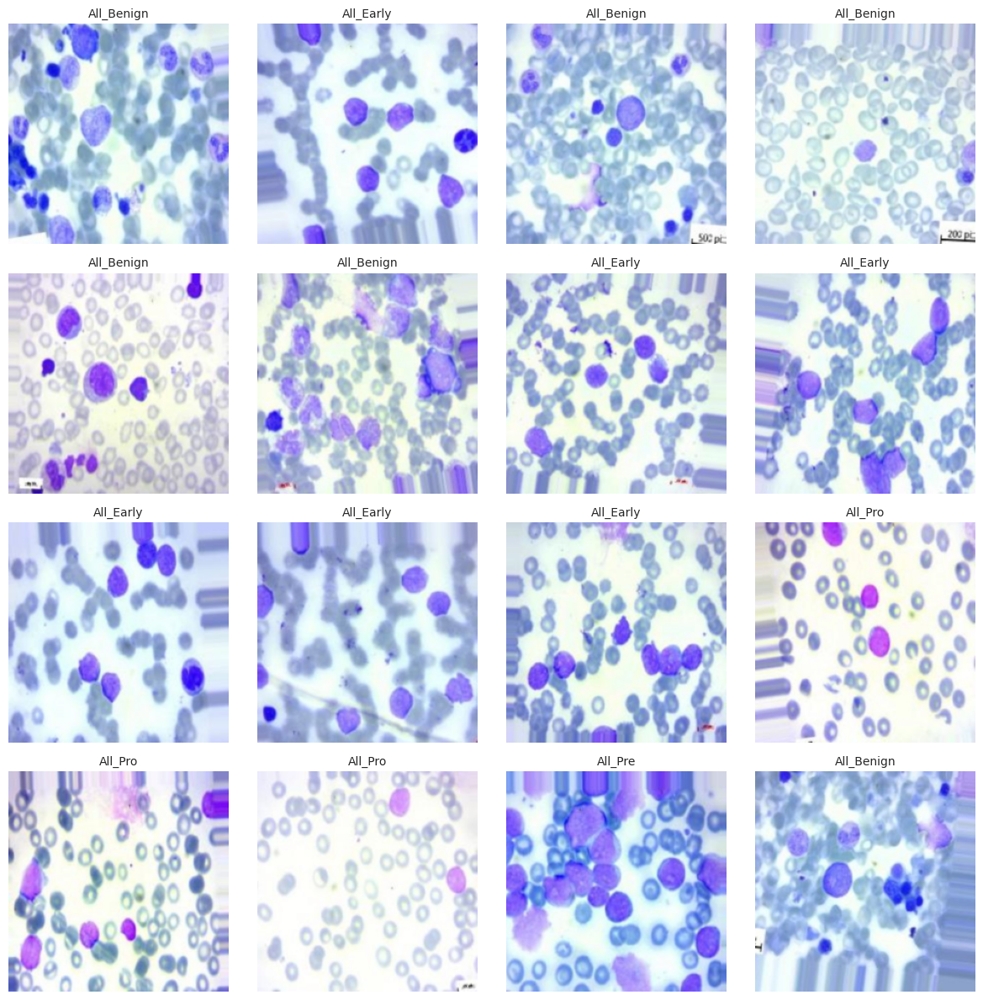

🔍 Showing Validation Set:


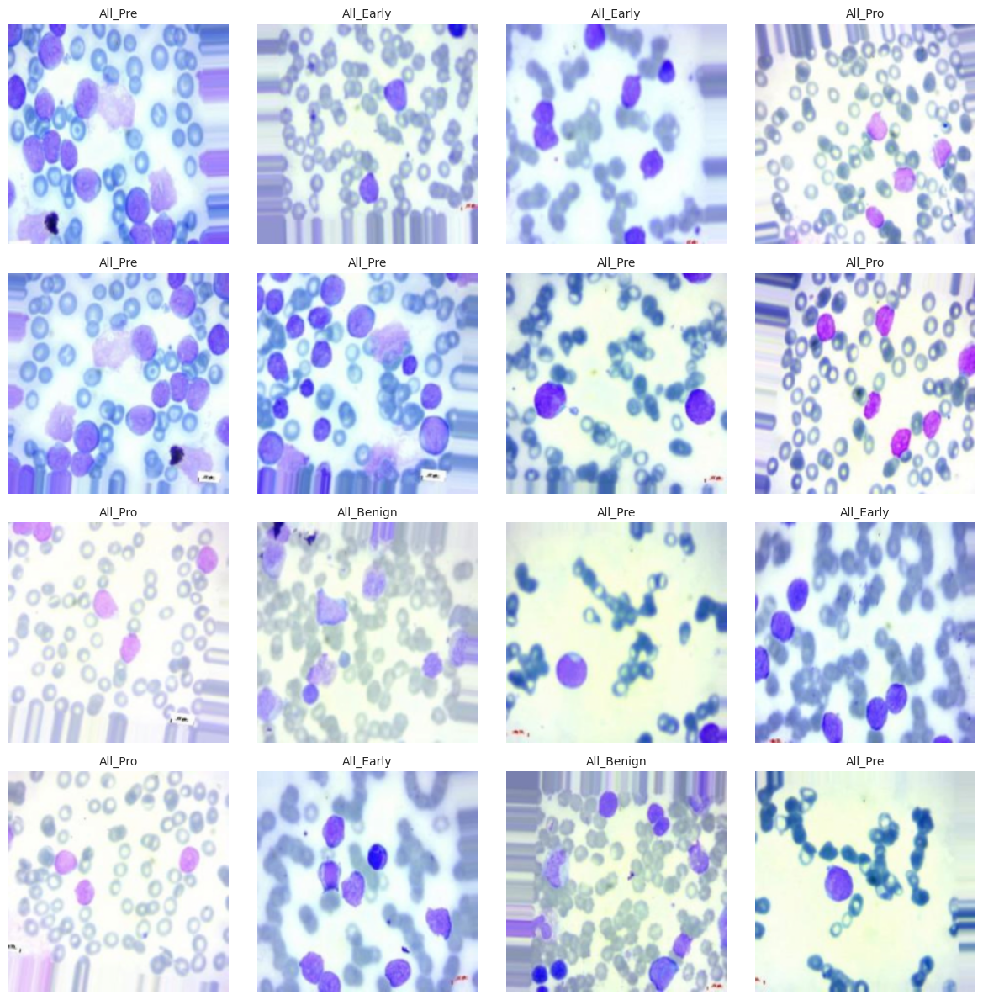

🔍 Showing Testing Set:


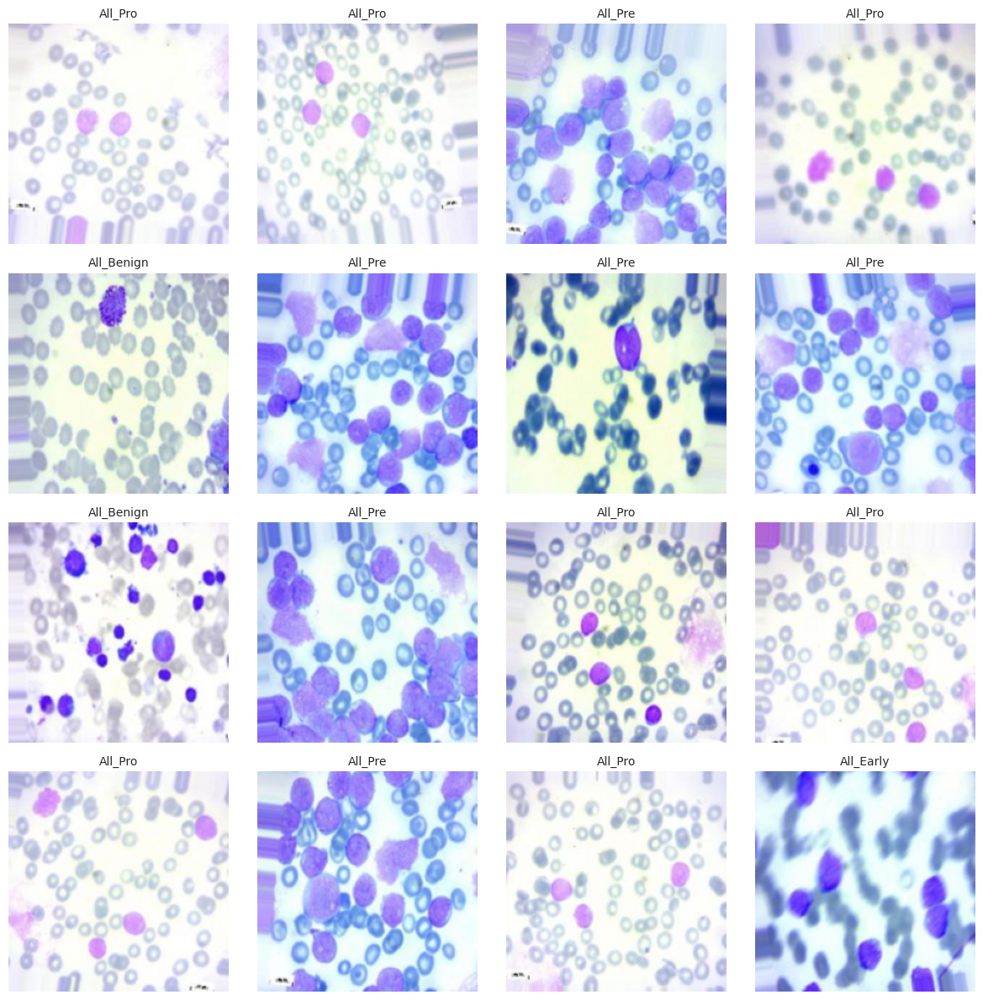


🔍 Visualizing Client 1:


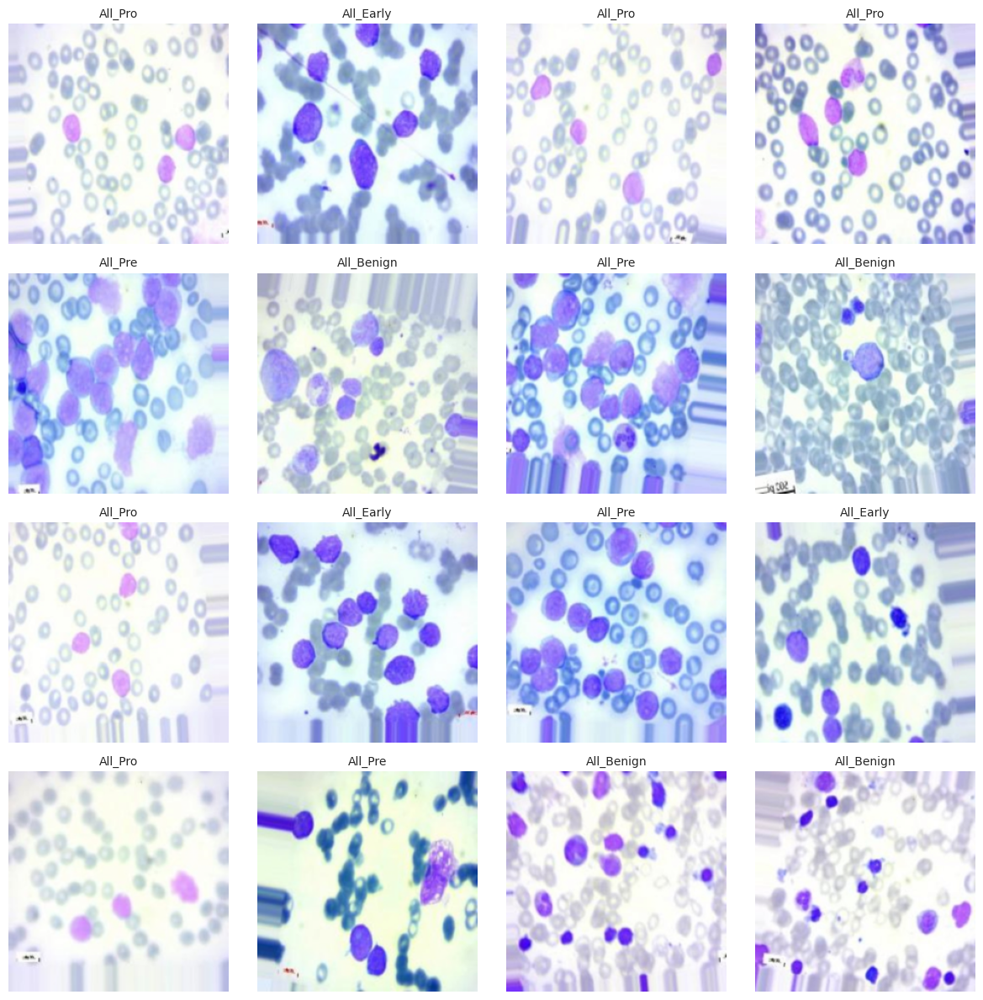


🔍 Visualizing Client 2:


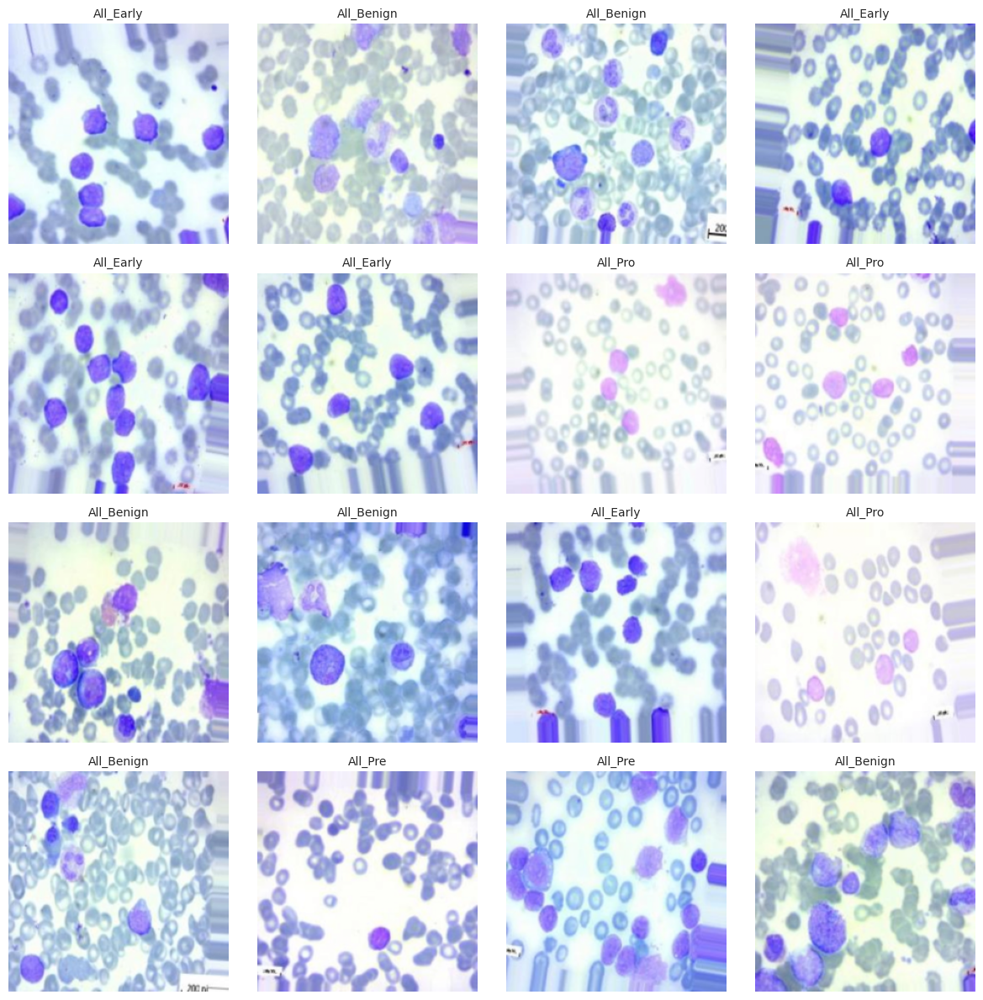


🔍 Visualizing Client 3:


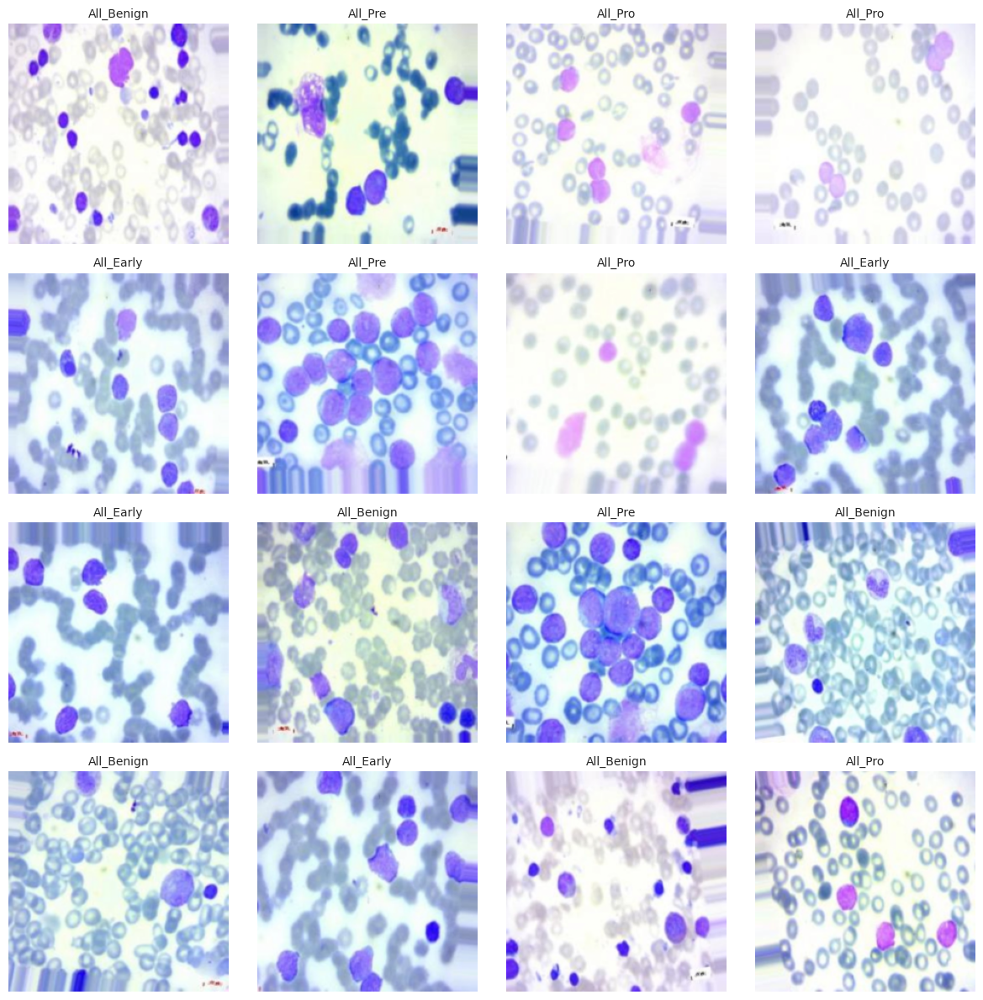

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Proper unnormalize
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

 # Display images with labels
    imshow_with_labels(torchvision.utils.make_grid(images, nrow=4), labels, class_names)

# Correct 4x4 visualization with labels
def show_images_grid_with_labels(dataset, class_names, batch_size=16):
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    images, labels = next(iter(dataloader))

    images = images.cpu()
    labels = labels.cpu()

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()

    for img, label, ax in zip(images, labels, axes):
        img = unnormalize(img)
        npimg = np.transpose(img.numpy(), (1, 2, 0))
        npimg = np.clip(npimg, 0, 1)

        ax.imshow(npimg)
        ax.set_title(class_names[label.item()], fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Show Train, Val, Test
print("🔍 Showing Train Set:")
show_images_grid_with_labels(train_dataset, class_names)

print("🔍 Showing Validation Set:")
show_images_grid_with_labels(val_dataset, class_names)

print("🔍 Showing Testing Set:")
show_images_grid_with_labels(test_dataset, class_names)

# For each client dataset
for i, client_ds in enumerate(client_datasets):
    print(f"\n🔍 Visualizing Client {i+1}:")
    show_images_grid_with_labels(client_ds, class_names)


#Quick 2×2 Visualization of Training and Testing Datasets with Labels

🔍 Train 2×2:


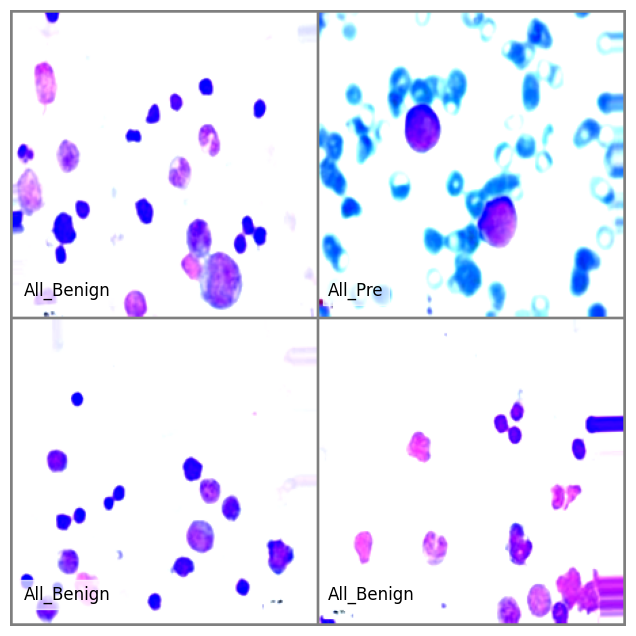

🔍 Validation 2×2:


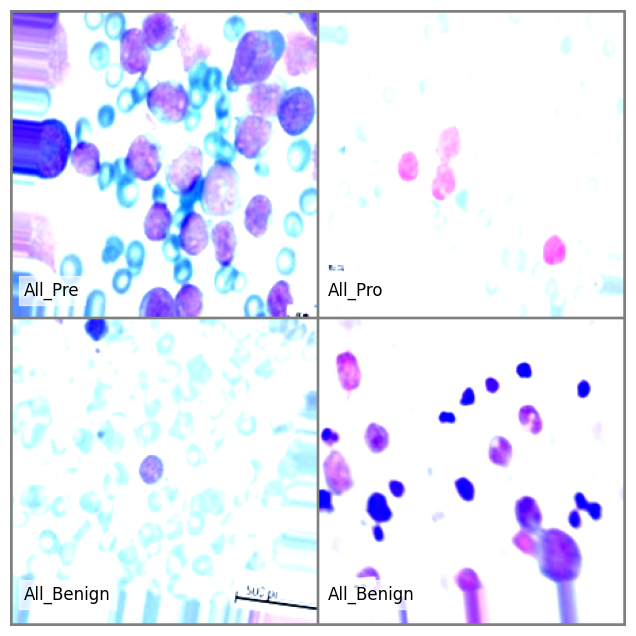

🔍 Test 2×2:


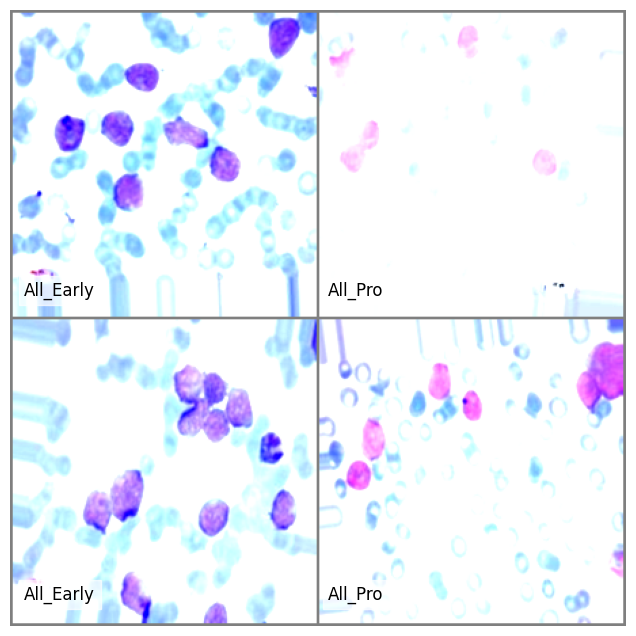

In [ ]:
# Function to show images with labels
import torchvision

def imshow_with_labels(imgs, labels, class_names):
    imgs = imgs / 2 + 0.5  # unnormalize
    npimg = imgs.numpy()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.axis('off')

    # Label positions for each mini-image
    for i in range(4):
        row = i // 2
        col = i % 2
        ax.text(
            col * 224 + 10,
            row * 224 + 210,
            class_names[labels[i]],
            bbox=dict(facecolor='white', alpha=0.7),
            fontsize=12, color='black'
        )
    plt.show()

def show_images_grid_2x2(dataset, class_names):
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)
    images, labels = next(iter(dataloader))
    imshow_with_labels(torchvision.utils.make_grid(images, nrow=2), labels, class_names)

# Display 2x2 images
print("🔍 Train 2×2:")
show_images_grid_2x2(train_dataset, class_names)

print("🔍 Validation 2×2:")
show_images_grid_2x2(val_dataset, class_names)

print("🔍 Test 2×2:")
show_images_grid_2x2(test_dataset, class_names)

# Create DataLoaders for Federated Clients

In [ ]:
from torch.utils.data import DataLoader

# Check if client_datasets is empty
if len(client_datasets) == 0:
    print("Error: client_datasets is empty. Please check your dataset splitting.")
else:
    # Create individual dataloaders for each client
    client_loaders = [
        DataLoader(ds, batch_size=16, shuffle=True) for ds in client_datasets
    ]

    # Optionally, print the number of dataloaders created
    print(f"Created {len(client_loaders)} client dataloaders.")

Created 3 client dataloaders.


#📊 Visualization of Image Count in Training and Testing Datasets

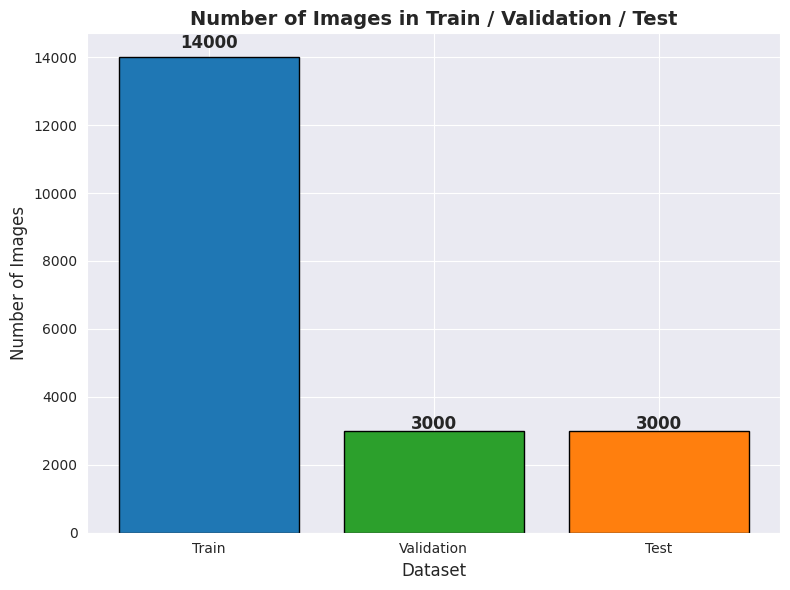

In [ ]:
import matplotlib.pyplot as plt

# Dataset counts
training_images = len(train_dataset)
validation_images = len(val_dataset)
testing_images = len(test_dataset)

# Labels and data
labels = ['Train', 'Validation', 'Test']
data = [training_images, validation_images, testing_images]

# Custom solid colors
colors = ['#1f77b4',  # Blue - Train
          '#2ca02c',  # Green - Validation
          '#ff7f0e']  # Orange - Test

plt.figure(figsize=(8, 6))
plt.bar(labels, data, color=colors, edgecolor='black')

# Title & labels
plt.title('Number of Images in Train / Validation / Test', fontsize=14, fontweight='bold')
plt.xlabel('Dataset', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Adding text labels above bars
for i, value in enumerate(data):
    plt.text(i, value + (value * 0.02), str(value),
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

:#Load Pre-trained RESNET-34 Model

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet34, ResNet34_Weights

# Load pretrained Resnet-34
model = resnet34(weights=ResNet34_Weights.DEFAULT)
# Replace classifier for 4 classes
model.fc = torch.nn.Linear(model.fc.in_features, 4)
# Move to GPU/CPU/MPS
model = model.to(device)
print(model.fc) # Changed from model.classifier to model.fc

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 188MB/s]


Linear(in_features=512, out_features=4, bias=True)


# Setup DataLoaders for Federated Clients and Global Testing

In [ ]:
batch_size = 32  # You can adjust based on local machine GPU memory

# Create DataLoaders for each client (use client_datasets from Non-IID split)
client_loaders = [
    torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,  # Safer on your machine (adjust based on performance)
        pin_memory=True  # Only needed if using a CUDA GPU, set to False for MPS or CPU
    )
    for dataset in client_datasets
]

# Keep test_loader as-is (for global evaluation after each round)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True  # Adjust this for your hardware (e.g., MPS or CPU)
)

# Create a train_loader for full global training evaluation if needed
train_loader = torch.utils.data.DataLoader(
    full_train_dataset,  # full training dataset
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True  # Adjust this based on your system (e.g., MPS or CPU)
)

# Load and Adjust EfficientNet_V2_S-Large Model

In [ ]:
import torch
# Correct import for ResNet-34
from torchvision.models import resnet34, ResNet34_Weights

# Load ResNet-34 with pretrained weights
weights = ResNet34_Weights.DEFAULT
model = resnet34(weights=weights)

# Adjust the final fully connected layer for 4 output classes
model.fc = torch.nn.Linear(model.fc.in_features, 4)

# Move the model to the device (GPU, MPS, or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Set model to evaluation mode for inference (if necessary)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Federated Evaluation and Metrics Logging

In [ ]:
import os
import csv
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import torch

# Define where you want to save the log file
metrics_log_path = "/content/drive/MyDrive/Result626.csv"

# Create log file with headers (if it doesn't exist)
if not os.path.exists(metrics_log_path):
    with open(metrics_log_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Round", "Client", "Accuracy", "Precision", "Recall", "F1-Score"])

# Federated evaluation function
def federated_evaluation(model, dataloader, device, class_names, round_num, client_name):
    y_true = []
    y_pred = []

    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)  # Get the class predictions
            y_true.extend(labels.cpu().numpy())  # Store true labels
            y_pred.extend(preds.cpu().numpy())  # Store predicted labels

    # Calculate evaluation metrics
    acc = np.mean(np.array(y_true) == np.array(y_pred))  # Accuracy
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)  # Precision
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)  # Recall
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)  # F1-Score

    # Log to CSV file after each round
    with open(metrics_log_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([round_num, client_name, acc, prec, rec, f1])

    return acc, prec, rec, f1

# Federated Learning Training Loop and Model Evaluation

Using device: cuda

⟳️ Federated Round 1/5
  🚀 Client 1 training...
🧠 Client 1 (client-side) using AdamW optimizer.
🧪 Client 1 - Train Acc: 33.27%, Val Acc: 34.05%, Test Acc: 29.96%
  🚀 Client 2 training...
🧠 Client 2 (client-side) using SGD optimizer.
🧪 Client 2 - Train Acc: 32.11%, Val Acc: 34.91%, Test Acc: 32.95%
  🚀 Client 3 training...
🧠 Client 3 (client-side) using RMSprop optimizer.
🧪 Client 3 - Train Acc: 33.67%, Val Acc: 30.33%, Test Acc: 32.67%
     🖥️ Server (server-side) performed FedAvg aggregation.
✅ Round 1 - Global Train Acc: 99.14% | Global Val Acc: 99.10% | Global Test Acc: 98.87%

⟳️ Federated Round 2/5
  🚀 Client 1 training...
🧠 Client 1 (client-side) using AdamW optimizer.
🧪 Client 1 - Train Acc: 98.87%, Val Acc: 99.28%, Test Acc: 99.00%
  🚀 Client 2 training...
🧠 Client 2 (client-side) using SGD optimizer.
🧪 Client 2 - Train Acc: 99.60%, Val Acc: 98.71%, Test Acc: 99.14%
  🚀 Client 3 training...
🧠 Client 3 (client-side) using RMSprop optimizer.
🧪 Client 3 - Train

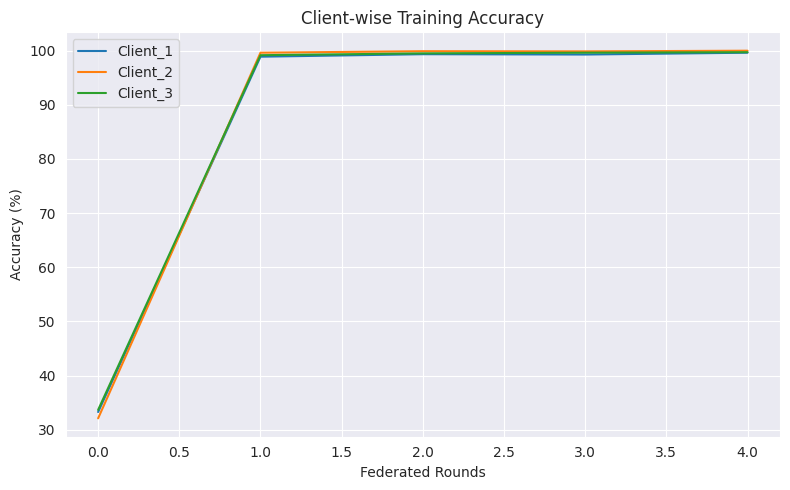

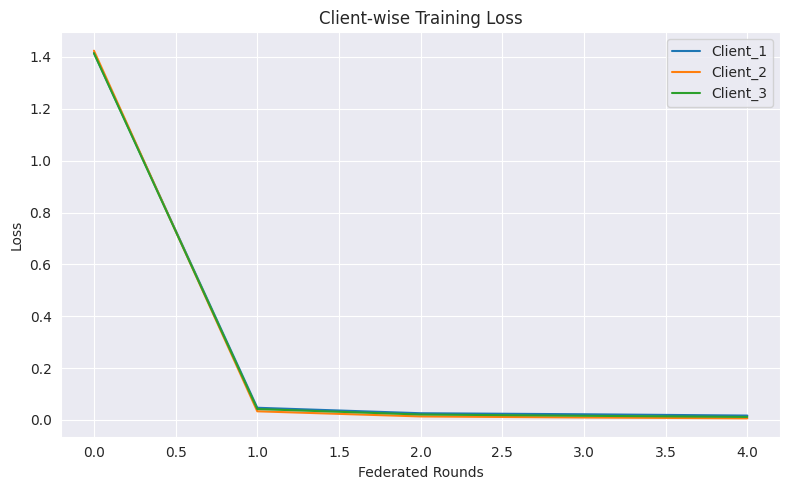

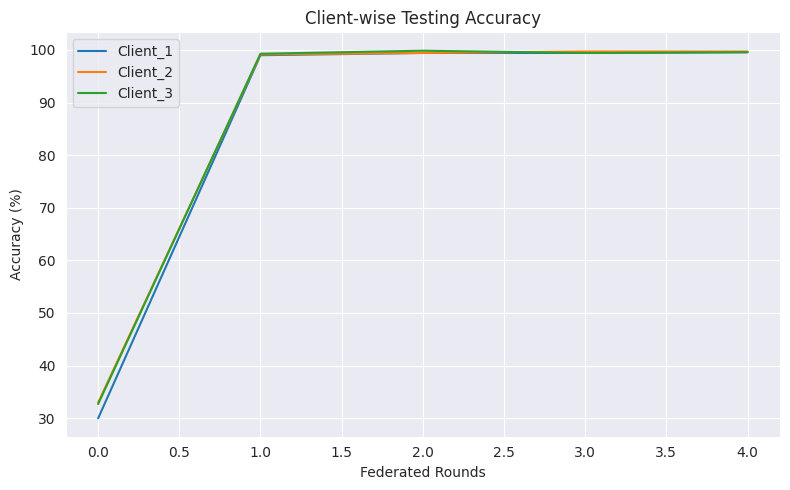

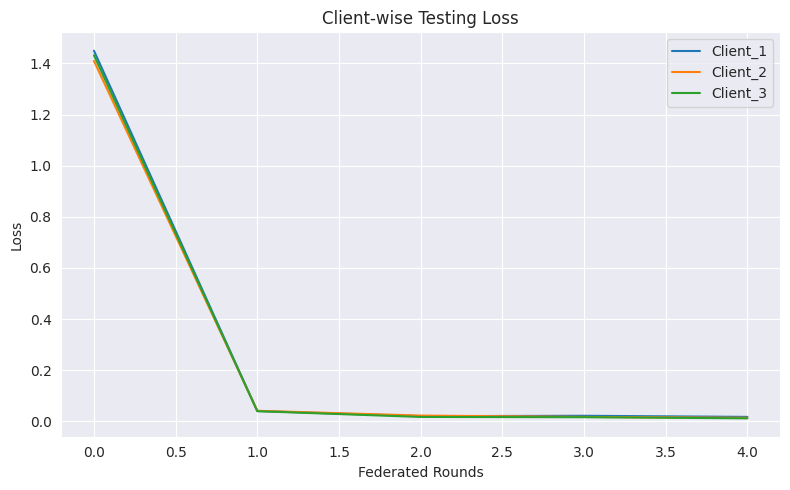

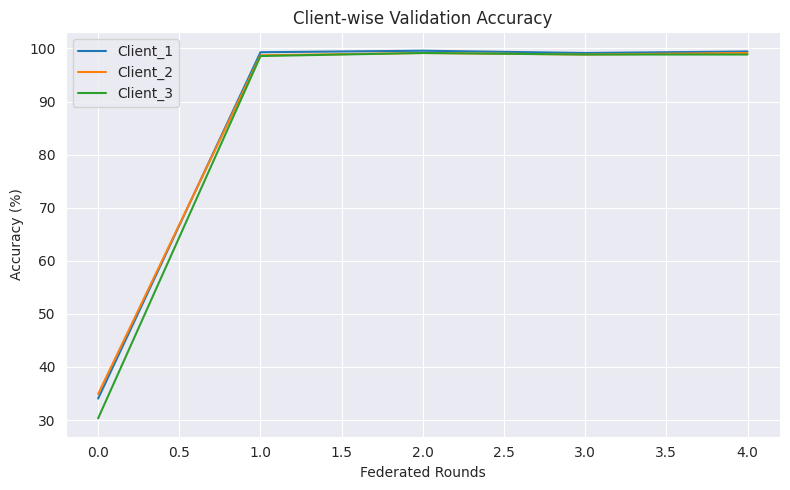

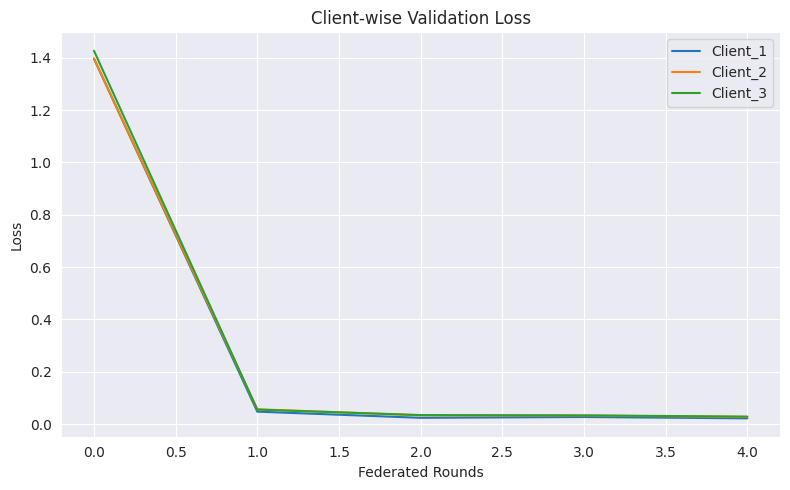

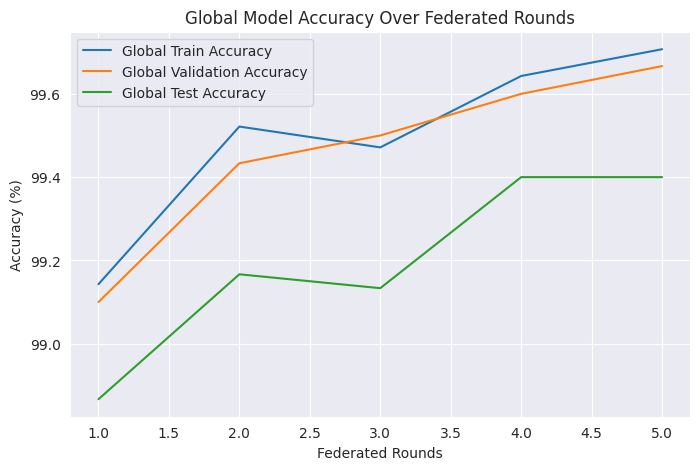

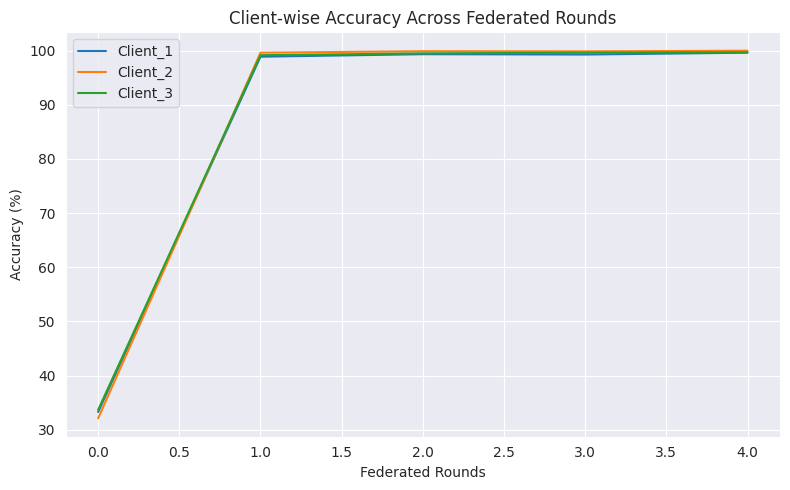

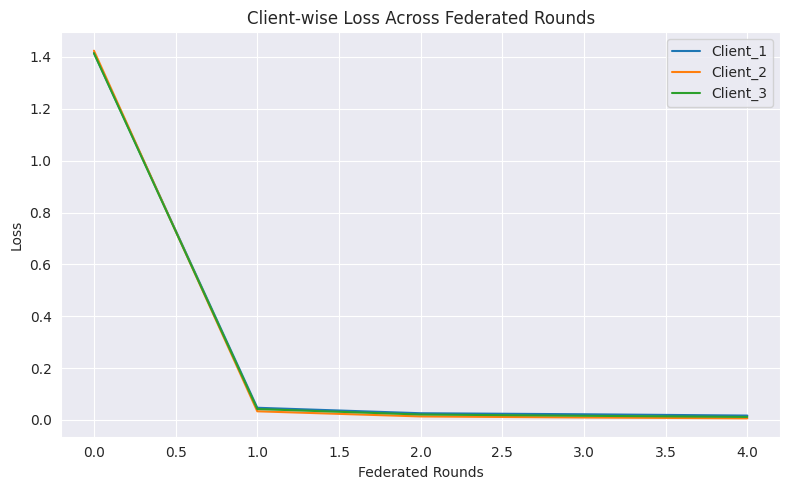

KeyError: 'Train Accuracy (%)'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision.models import resnet34, ResNet34_Weights
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

import pandas as pd
import csv # Added missing import for csv

# 📁 Set output paths in your Google Drive project folder
base_path = "/content/drive/MyDrive/Result626"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load resnet34 with pretrained weights
weights = ResNet34_Weights.DEFAULT # Using the correct weights for resnet34
global_model = resnet34(weights=weights)

# Modify the classifier for 4 output classes (based on class_names)
global_model.fc = nn.Linear(global_model.fc.in_features, 4) # Adjusting index for resnet34 and output features to 2
global_model = global_model.to(device)
# Loss function
criterion = nn.CrossEntropyLoss()

# Freeze all layers except the final classifier layer
for param in global_model.parameters():
    param.requires_grad = False
# Unfreeze the final classifier layer
for param in global_model.fc.parameters(): # Adjusting index for resnet34
    param.requires_grad = True

# Unfreeze the last 3 layers in the feature extractor (This is optional and depends on your fine-tuning strategy)
# for param in global_model.features[-3:].parameters():
#     param.requires_grad = True

# Trackers
global_train_accuracies, global_test_accuracies = [], []
global_val_accuracies = [] # Initialize global_val_accuracies

# Function to train a local model on client data with client-specific optimizer
def train_local_model(model, client_dataset, client_id, round_num, epochs=1):
    model = deepcopy(model)
    model.train()

    # The optimizers are defined per client as in the original code. Keep this part.
    if client_id == 0:
        optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
    elif client_id == 1:
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif client_id == 2:
        optimizer = optim.RMSprop(model.parameters(), lr=0.0005, alpha=0.99)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.0001) # Default if client_id is unexpected


    # 🔍 Log which optimizer this client is using
    if isinstance(optimizer, optim.AdamW):
        optimizer_name = "AdamW"
    elif isinstance(optimizer, optim.SGD):
        optimizer_name = "SGD"
    elif isinstance(optimizer, optim.RMSprop):
        optimizer_name = "RMSprop"
    elif isinstance(optimizer, optim.Adam):
        optimizer_name = "Adam"
    else:
        optimizer_name = "Unknown"

    print(f"🧠 Client {client_id+1} (client-side) using {optimizer_name} optimizer.")

    # Save optimizer info to CSV
    # Corrected indentation for this block
    with open(optimizer_log_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([round_num + 1, client_id + 1, optimizer_name, "client-side"])

    # Corrected indentation for this line
    loader = DataLoader(client_dataset, batch_size=32, shuffle=True)

    for _ in range(epochs):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return model.state_dict()

# Function to average weights across all clients (defined once, outside train_local_model)
def average_weights(state_dicts):
    avg_dict = deepcopy(state_dicts[0])
    for key in avg_dict.keys():
        for i in range(1, len(state_dicts)):
            avg_dict[key] += state_dicts[i][key]
        avg_dict[key] = avg_dict[key] / len(state_dicts)
    return avg_dict

# Function to calculate accuracy and loss
def calculate_accuracy(loader, model, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    # Use criterion defined globally

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    average_loss = running_loss / len(loader) # Calculate average loss per batch
    model.train() # Set model back to training mode
    return accuracy, average_loss

# Define log file paths (ensure these are defined before the training loop starts)
optimizer_log_path = base_path + "client_optimizer_log.csv"
fedavg_log_path = base_path + "client_server_roles_log.csv"
global_accuracy_log_path = base_path + "global_accuracy_log.csv"

# Create CSV files with headers if not already exists (moved this up)
if not os.path.exists(optimizer_log_path):
    with open(optimizer_log_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Round", "Client", "Optimizer", "Role"])

if not os.path.exists(fedavg_log_path):
    with open(fedavg_log_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Round", "Actor", "Action", "Role"])

if not os.path.exists(global_accuracy_log_path):
    with open(global_accuracy_log_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Round", "Global Train Accuracy (%)", "Global Test Accuracy (%)"])


# Federated Learning Training Loop parameters

num_rounds = 5 # Or use a variable defined earlier if it exists
local_epochs = 9 # Or use a variable defined earlier if it exists

# Define num_clients here, as it is used later in the code
num_clients = 3 # You had 3 clients earlier in your code

# -----------------------------
# ✅ Split each client's dataset
# -----------------------------
from torch.utils.data import random_split

# -----------------------------
# NEW: Split dataset into Train 70%, Test 15%, Validation 15%
# -----------------------------

client_train_datasets = []
client_test_datasets = []
client_val_datasets = []

for dataset in client_datasets:
    total_len = len(dataset)
    train_len = int(0.70 * total_len)
    val_len = int(0.15 * total_len)
    test_len = total_len - train_len - val_len  # Remaining samples

    train_subset, val_subset, test_subset = random_split(
        dataset, [train_len, val_len, test_len]
    )

    client_train_datasets.append(train_subset)
    client_val_datasets.append(val_subset)
    client_test_datasets.append(test_subset)

# -----------------------------
# ✅ Initialize tracking matrices (already present, keep it)
# -----------------------------
client_accuracy_matrix = [[] for _ in range(NUM_CLIENTS)]
client_loss_matrix = [[] for _ in range(NUM_CLIENTS)]
client_test_accuracy_matrix = [[] for _ in range(NUM_CLIENTS)]
client_test_loss_matrix = [[] for _ in range(NUM_CLIENTS)]
client_val_accuracy_matrix = [[] for _ in range(NUM_CLIENTS)] # Initialize val tracking
client_val_loss_matrix = [[] for _ in range(NUM_CLIENTS)]   # Initialize val tracking
global_train_accuracies, global_test_accuracies = [], []

# -----------------------------
# ⟳️ Federated Learning Training Loop
# -----------------------------
for round in range(num_rounds):
    print(f"\n⟳️ Federated Round {round + 1}/{num_rounds}")
    client_states = []

    for i in range(NUM_CLIENTS):
        print(f"  🚀 Client {i+1} training...")
        train_data = client_train_datasets[i]
        test_data = client_test_datasets[i]
        val_data = client_val_datasets[i] # Ensure val_data is defined

        # Train local model - Pass the global_model to be trained locally
        local_model = deepcopy(global_model) # Create a copy for local training
        local_state = train_local_model(local_model, train_data, client_id=i, round_num=round, epochs=local_epochs)
        client_states.append(local_state)

        # Evaluate on client training data AFTER local training with the local model
        # Create DataLoader for local evaluation
        local_train_loader_eval = DataLoader(train_data, batch_size=32, shuffle=False)
        local_acc, local_loss = calculate_accuracy(local_train_loader_eval, local_model, device) # Evaluate with local model
        client_accuracy_matrix[i].append(local_acc)
        client_loss_matrix[i].append(local_loss)

        # Evaluate on client testing data AFTER local training with the local model
        local_test_loader_eval = DataLoader(test_data, batch_size=32, shuffle=False)
        local_test_acc, local_test_loss = calculate_accuracy(local_test_loader_eval, local_model, device) # Evaluate with local model
        client_test_accuracy_matrix[i].append(local_test_acc)
        client_test_loss_matrix[i].append(local_test_loss)


        # Evaluate on client val data AFTER local training with the local model
        local_val_loader_eval = DataLoader(val_data, batch_size=32, shuffle=False)
        local_val_acc, local_val_loss = calculate_accuracy(local_val_loader_eval, local_model, device) # Evaluate with local model
        client_val_accuracy_matrix[i].append(local_val_acc)
        client_val_loss_matrix[i].append(local_val_loss)

        print(f"🧪 Client {i+1} - Train Acc: {local_acc:.2f}%, Val Acc: {local_val_acc:.2f}%, Test Acc: {local_test_acc:.2f}%") # Corrected print statement

    # Federated Averaging
    global_model.load_state_dict(average_weights(client_states))
    print(f"     🖥️ Server (server-side) performed FedAvg aggregation.")

    # Log FedAvg action to CSV (already present, keep it)
    with open(fedavg_log_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([round + 1, "Server", "FedAvg aggregation performed", "server-side"])

    # Global Evaluation on the aggregated global model AFTER aggregation
    # Use the pre-defined train_loader (full training dataset) and test_loader (full test dataset)
    global_train_acc, _ = calculate_accuracy(DataLoader(full_train_dataset, batch_size=32), global_model, device)
    global_test_acc, _ = calculate_accuracy(DataLoader(test_dataset, batch_size=32), global_model, device)
    global_val_acc, _ = calculate_accuracy(DataLoader(val_dataset, batch_size=32), global_model, device) # Global validation accuracy


    global_train_accuracies.append(global_train_acc)
    global_test_accuracies.append(global_test_acc)
    global_val_accuracies.append(global_val_acc) # Append global_val_acc

    # Save global accuracy to CSV (already present, keep it)
    with open(global_accuracy_log_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([round + 1, f"{global_train_acc:.2f}", f"{global_test_acc:.2f}"])

    print(f"✅ Round {round + 1} - Global Train Acc: {global_train_acc:.2f}% | Global Val Acc: {global_val_acc:.2f}% | Global Test Acc: {global_test_acc:.2f}%") # Adjusted global print statement

# -----------------------------
# 💾 Save all client-side matrices as CSV (already present, keep it)
# -----------------------------
acc_df = pd.DataFrame(client_accuracy_matrix).T
acc_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
acc_df.to_csv(base_path + "client_accuracy_matrix.csv", index_label="Round")

loss_df = pd.DataFrame(client_loss_matrix).T
loss_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
loss_df.to_csv(base_path + "client_loss_matrix.csv", index_label="Round")

test_acc_df = pd.DataFrame(client_test_accuracy_matrix).T
test_acc_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
test_acc_df.to_csv(base_path + "client_test_accuracy_matrix.csv", index_label="Round")

test_loss_df = pd.DataFrame(client_test_loss_matrix).T
test_loss_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
test_loss_df.to_csv(base_path + "client_test_loss_matrix.csv", index_label="Round")

val_acc_df = pd.DataFrame(client_val_accuracy_matrix).T # Save validation accuracy
val_acc_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
val_acc_df.to_csv(base_path + "client_val_accuracy_matrix.csv", index_label="Round")

val_loss_df = pd.DataFrame(client_val_loss_matrix).T # Save validation loss
val_loss_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
val_loss_df.to_csv(base_path + "client_val_loss_matrix.csv", index_label="Round")


# -----------------------------
# 📈 Plot: Per-client Accuracy & Loss (Train + Test) (already present, keep it)
# -----------------------------
def plot_metric_matrix(df, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    for col in df.columns:
        plt.plot(df.index, df[col], label=col)
    plt.title(title)
    plt.xlabel("Federated Rounds")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(base_path + filename)
    plt.show()

plot_metric_matrix(acc_df, "Client-wise Training Accuracy", "Accuracy (%)", "client_training_accuracy_plot.png") # Changed filename for clarity
plot_metric_matrix(loss_df, "Client-wise Training Loss", "Loss", "client_training_loss_plot.png") # Changed filename for clarity
plot_metric_matrix(test_acc_df, "Client-wise Testing Accuracy", "Accuracy (%)", "client_testing_accuracy_plot.png") # Changed filename for clarity
plot_metric_matrix(test_loss_df, "Client-wise Testing Loss", "Loss", "client_testing_loss_plot.png") # Changed filename for clarity
plot_metric_matrix(val_acc_df, "Client-wise Validation Accuracy", "Accuracy (%)", "client_val_accuracy_plot.png") # Added validation accuracy plot
plot_metric_matrix(val_loss_df, "Client-wise Validation Loss", "Loss", "client_val_loss_plot.png")     # Added validation loss plot

# -----------------------------
# 📊 Compute and Save Average Performance (already present, keep it)
# -----------------------------
avg_df = pd.DataFrame({
    "Train Accuracy (%)": acc_df.mean(),
    "Train Loss": loss_df.mean(),
    "Validation Accuracy (%)": val_acc_df.mean(), # Added validation metrics to average
    "Validation Loss": val_loss_df.mean(),
    "Test Accuracy (%)": test_acc_df.mean(),
    "Test Loss": test_loss_df.mean()
})
avg_df.to_csv(base_path + "client_avg_performance_table.csv")


# Plot accuracy trend (Global) (already present, keep it)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(global_train_accuracies) + 1), global_train_accuracies, label='Global Train Accuracy')
plt.plot(range(1, len(global_val_accuracies) + 1), global_val_accuracies, label='Global Validation Accuracy') # Plot global validation
plt.plot(range(1, len(global_test_accuracies) + 1), global_test_accuracies, label='Global Test Accuracy')
plt.title('Global Model Accuracy Over Federated Rounds') # Changed title for clarity
plt.xlabel('Federated Rounds')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.savefig(base_path + "global_accuracy_plot.png") # Save the global accuracy plot
plt.show()


# -----------------------------
# ➡️ Post-training analysis block (Client-wise logging & export) (already present, keep it, adjusted filenames)
# -----------------------------

# Redefine paths with corrected filenames
accuracy_csv_path = base_path + "client_accuracy_matrix.csv" # Already saved above
loss_csv_path = base_path + "client_loss_matrix.csv"       # Already saved above
test_accuracy_csv_path = base_path + "client_test_accuracy_matrix.csv" # Added test set CSV paths
test_loss_csv_path = base_path + "client_test_loss_matrix.csv"     # Added test set CSV paths
val_accuracy_csv_path = base_path + "client_val_accuracy_matrix.csv" # Added validation set CSV paths
val_loss_csv_path = base_path + "client_val_loss_matrix.csv"     # Added validation set CSV paths

accuracy_plot_path = base_path + "client_training_accuracy_plot.png" # Use corrected filenames
loss_plot_path = base_path + "client_training_loss_plot.png"         # Use corrected filenames
test_accuracy_plot_path = base_path + "client_testing_accuracy_plot.png" # Added test set plot paths
test_loss_plot_path = base_path + "client_testing_loss_plot.png"     # Added test set plot paths
val_accuracy_plot_path = base_path + "client_val_accuracy_plot.png" # Added validation set plot paths
val_loss_plot_path = base_path + "client_val_loss_plot.png"     # Added validation set plot paths


avg_csv_path = base_path + "client_avg_performance_table.csv" # Already saved above
avg_latex_path = base_path + "client_avg_performance_table.tex"

# ℹ️ Convert client-wise accuracy/loss matrices to pandas DataFrames (already done above before saving)
# Reloading them here is redundant if the saving above is successful.
# Let's assume they are loaded if this block is run independently.
# acc_df = pd.read_csv(accuracy_csv_path, index_col="Round")
# loss_df = pd.read_csv(loss_csv_path, index_col="Round")
# test_acc_df = pd.read_csv(test_accuracy_csv_path, index_col="Round") # Load test set data
# test_loss_df = pd.read_csv(test_loss_csv_path, index_col="Round")     # Load test set data

# №️ Convert client-wise accuracy/loss matrices to pandas DataFrames
acc_df = pd.DataFrame(client_accuracy_matrix).T
acc_df.columns = [f"Client_{i+1}" for i in range(num_clients)]

loss_df = pd.DataFrame(client_loss_matrix).T
loss_df.columns = [f"Client_{i+1}" for i in range(num_clients)]

# 💾 Save accuracy and loss matrices as CSV
acc_df.to_csv(accuracy_csv_path, index_label="Round")
loss_df.to_csv(loss_csv_path, index_label="Round")

# 📈 Plot: Per-client accuracy across rounds
plt.figure(figsize=(8, 5))
for col in acc_df.columns:
    plt.plot(acc_df.index, acc_df[col], label=col)
plt.title("Client-wise Accuracy Across Federated Rounds")
plt.xlabel("Federated Rounds")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(accuracy_plot_path)
plt.show()

# 📉 Plot: Per-client loss across rounds
plt.figure(figsize=(8, 5))
for col in loss_df.columns:
    plt.plot(loss_df.index, loss_df[col], label=col)
plt.title("Client-wise Loss Across Federated Rounds")
plt.xlabel("Federated Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(loss_plot_path)
plt.show()

# 📊 Compute and save average performance
avg_acc = acc_df.mean()
avg_loss = loss_df.mean()
avg_df = pd.DataFrame({"Avg Accuracy (%)": avg_acc, "Avg Loss": avg_loss})

# 💾 Save accuracy and loss matrices as CSV (already done above)
# Re-saving here is redundant.

# 📈 Plot: Per-client accuracy across rounds (already done above)
# The plotting functions are defined and called above.
# This section seems to duplicate the plotting logic.
# Let's remove the redundant plotting code here.

# 📊 Compute and save average performance (already done above)
# Re-computing and saving here is redundant.

# Generate LaTeX table from the average performance DataFrame (already created avg_df above)
with open(avg_latex_path, "w") as f:
    # Add some basic LaTeX table formatting
    f.write("\\begin{tabular}{|l|c|c|c|c|c|c|}\n") # Adjusted column count for validation metrics
    f.write("\\hline\n")
    f.write("Client & Train Accuracy (\\%) & Train Loss & Validation Accuracy (\\%) & Validation Loss & Test Accuracy (\\%) & Test Loss \\n") # Added validation headers
    f.write("\\hline\n")
    for index, row in avg_df.iterrows():
        f.write(f"{index} & {row['Train Accuracy (%)']:.2f} & {row['Train Loss']:.2f} & {row['Validation Accuracy (%)']:.2f} & {row['Validation Loss']:.2f} & {row['Test Accuracy (%)']:.2f} & {row['Test Loss']:.2f} \\n") # Added validation data
    f.write("\\hline\n")
    f.write("\\end{tabular}\n")

print(f"✅ Saved average performance table as LaTeX to: {avg_latex_path}")

# Ensure all plots are saved
print("✅ All client-wise and global performance plots and tables saved.")

# precision recall Curve

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# -------------------------------
# FUNCTION: PRECISION-RECALL CURVE
# -------------------------------
def plot_precision_recall_advanced(y_true, y_scores, n_classes, class_names=None):
    """
    Plots Precision-Recall curves (Micro, Macro, and per-class) in blue theme.

    Parameters:
    - y_true: Ground truth labels (shape: [N])
    - y_scores: Predicted probabilities (shape: [N, n_classes])
    - n_classes: Number of classes
    - class_names: List of class names
    """

    # -------------------------------
    # BINARIZE LABELS
    # -------------------------------
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    # -------------------------------
    # INITIALIZE
    # -------------------------------
    precision = dict()
    recall = dict()
    avg_precision = dict()

    # -------------------------------
    # PER-CLASS PR CURVE
    # -------------------------------
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(
            y_true_bin[:, i], y_scores[:, i]
        )
        avg_precision[i] = average_precision_score(
            y_true_bin[:, i], y_scores[:, i]
        )

    # -------------------------------
    # MICRO-AVERAGE
    # -------------------------------
    precision["micro"], recall["micro"], _ = precision_recall_curve(
        y_true_bin.ravel(), y_scores.ravel()
    )
    avg_precision["micro"] = average_precision_score(
        y_true_bin, y_scores, average="micro"
    )

    # -------------------------------
    # MACRO-AVERAGE
    # -------------------------------
    avg_precision["macro"] = average_precision_score(
        y_true_bin, y_scores, average="macro"
    )

    # -------------------------------
    # PLOT
    # -------------------------------
    plt.figure(figsize=(8,6))

    # Micro-average curve (main blue)
    plt.plot(
        recall["micro"],
        precision["micro"],
        color="blue",
        linewidth=3,
        label=f"Micro-average (AP = {avg_precision['micro']:.3f})"
    )

    # Per-class curves (lighter blue shades)
    for i in range(n_classes):
        label_name = class_names[i] if class_names else f"Class {i}"
        plt.plot(
            recall[i],
            precision[i],
            linestyle='--',
            linewidth=1.5,
            label=f"{label_name} (AP = {avg_precision[i]:.3f})"
        )

    # -------------------------------
    # GRAPH SETTINGS
    # -------------------------------
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title("Precision-Recall Curve (Advanced - Blue Theme)", fontsize=14)

    plt.grid(alpha=0.3)
    plt.legend(loc="lower left", fontsize=9)

    # Add baseline reference
    plt.axhline(y=np.mean(y_true_bin), color='gray', linestyle=':', label="Baseline")

    plt.tight_layout()
    plt.show()

    # -------------------------------
    # PRINT SCORES
    # -------------------------------
    print("\n===== Average Precision Scores =====")
    for i in range(n_classes):
        label_name = class_names[i] if class_names else f"Class {i}"
        print(f"{label_name}: AP = {avg_precision[i]:.4f}")

    print(f"\nMicro Average AP: {avg_precision['micro']:.4f}")
    print(f"Macro Average AP: {avg_precision['macro']:.4f}")

#Model Saving Path

In [ ]:
import torch
from torchvision.models import resnet34, ResNet34_Weights

# The 'global_model' is the one trained in the Federated Learning loop.
# We need to save this specific model.
# Ensure 'global_model' and 'optimizer' (or an optimizer that matches the global model's state) are available in scope.
# For saving, we'll use a dummy optimizer for consistency if the actual global optimizer state isn't critical to reload later.
# However, typically you'd want to save the optimizer state from the *last client* or *server* if you intend to resume training.
# For simplicity, let's use a new Adam optimizer for the global_model to save its state.

# Ensure global_model is the one from the FL training loop
# If this cell is run independently, global_model needs to be defined.
# For this fix, we assume 'global_model' is the trained model from cell 11ivliFkBSXw.

# Re-instantiate an optimizer for the global_model to save its state (optional, but good practice)
# This optimizer will just be used for saving its state alongside the model.
# The learning rate here is arbitrary as it's not used for training.
global_model_optimizer = torch.optim.Adam(global_model.parameters(), lr=0.001)

# Save function
def save_model(model, optimizer, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, path)
    print(f"Model saved to {path}")

# Save path - use the base_path defined earlier for consistency
save_path = f"{base_path}global_resnet34_trained.pth"

# Save the trained global model
save_model(global_model, global_model_optimizer, save_path)

Model saved to /content/drive/MyDrive/Result626global_resnet34_trained.pth


#Model Loading

In [ ]:
import torch
from torchvision.models import resnet34, ResNet34_Weights

# Load ResNet-34 with pretrained weights (only for initial architecture definition)
weights = ResNet34_Weights.DEFAULT
model = resnet34(weights=weights)

# Modify the final fully connected layer for 4 output classes
model.fc = torch.nn.Linear(model.fc.in_features, 4)

# Define the optimizer (only for initial optimizer architecture definition)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Function to load model and optimizer states
def load_model(model, optimizer, path, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    model.to(device)
    print(f"✅ Model loaded from: {path}")
    return model, optimizer

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path to the saved model checkpoint (should match the save path)
load_path = f"{base_path}global_resnet34_trained.pth"

# Load the model and optimizer
model, optimizer = load_model(model, optimizer, load_path, device)

# Set model to evaluation mode
model.eval()

✅ Model loaded from: /content/drive/MyDrive/Result626global_resnet34_trained.pth


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader

# Your 4 classes
class_names = ['All_Benign','All_Early','All_Pre','All_Pro']

# Directory to save results
os.makedirs(base_path + "confusion_matrices", exist_ok=True)

# ------------------------------------------
# 📌 Function to calculate confusion matrix
# ------------------------------------------
def calculate_confusion_matrix(loader, model, device):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)  # Get the class predictions
            all_preds.extend(preds.cpu().numpy())  # Store predicted labels
            all_labels.extend(labels.cpu().numpy())  # Store true labels

    return confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3])

# ------------------------------------------
# 📌 Function to plot confusion matrix
# ------------------------------------------
def plot_confusion_matrix(cm, class_names, title, filename):
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename)
    print(f"✅ Saved confusion matrix: {filename}")
    plt.close()

# ---------------------------------------------------
# ⟳️ Generate confusion matrices FOR ALL CLIENTS (1–3)
# ---------------------------------------------------
for i in range(NUM_CLIENTS):
    client_name = f"Client_{i+1}"
    print(f"\n📊 Generating confusion matrices for {client_name}...")

    # TRAIN
    train_loader = DataLoader(client_train_datasets[i], batch_size=32, shuffle=False)
    cm_train = calculate_confusion_matrix(train_loader, global_model, device)
    plot_confusion_matrix(
        cm_train, class_names,
        f"{client_name} - Train Confusion Matrix",
        f"{base_path}confusion_matrices/{client_name}_train_cm.png"
    )

    # TEST
    test_loader = DataLoader(client_test_datasets[i], batch_size=32, shuffle=False)
    cm_test = calculate_confusion_matrix(test_loader, global_model, device)
    plot_confusion_matrix(
        cm_test, class_names,
        f"{client_name} - Test Confusion Matrix",
        f"{base_path}confusion_matrices/{client_name}_test_cm.png"
    )

    # VALIDATION
    val_loader = DataLoader(client_val_datasets[i], batch_size=32, shuffle=False)
    cm_val = calculate_confusion_matrix(val_loader, global_model, device)
    plot_confusion_matrix(
        cm_val, class_names,
        f"{client_name} - Validation Confusion Matrix",
        f"{base_path}confusion_matrices/{client_name}_val_cm.png"
    )

# ---------------------------------------------------
# 🌍 GLOBAL MODEL CONFUSION MATRICES (SERVER)
# ---------------------------------------------------
print("\n🌍 Generating Global Model Confusion Matrices...")

# Global Train
global_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
cm_gtrain = calculate_confusion_matrix(global_train_loader, global_model, device)
plot_confusion_matrix(
    cm_gtrain, class_names,
    "Server Global Model - Train Confusion Matrix",
    f"{base_path}confusion_matrices/Server_Global_Train_cm.png"
)

# Global Validation
global_val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
cm_gval = calculate_confusion_matrix(global_val_loader, global_model, device)
plot_confusion_matrix(
    cm_gval, class_names,
    "Server Global Model - Validation Confusion Matrix",
    f"{base_path}confusion_matrices/Server_Global_Val_cm.png"
)

# Global Test
global_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
cm_gtest = calculate_confusion_matrix(global_test_loader, global_model, device)
plot_confusion_matrix(
    cm_gtest, class_names,
    "Server Global Model - Test Confusion Matrix",
    f"{base_path}confusion_matrices/Server_Global_Test_cm.png"
)

# Save CSV versions
pd.DataFrame(cm_gtest).to_csv(f"{base_path}confusion_matrices/Server_Global_Test_cm.csv", index=False)
pd.DataFrame(cm_gtrain).to_csv(f"{base_path}confusion_matrices/Server_Global_Train_cm.csv", index=False)
pd.DataFrame(cm_gval).to_csv(f"{base_path}confusion_matrices/Server_Global_Val_cm.csv", index=False)

print("🎉 All confusion matrices generated successfully!")


📊 Generating confusion matrices for Client_1...
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_matrices/Client_1_train_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_matrices/Client_1_test_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_matrices/Client_1_val_cm.png

📊 Generating confusion matrices for Client_2...
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_matrices/Client_2_train_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_matrices/Client_2_test_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_matrices/Client_2_val_cm.png

📊 Generating confusion matrices for Client_3...
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_matrices/Client_3_train_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_matrices/Client_3_test_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Result626confusion_

#ROC Curve Generation for Server and Clients

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
import os

# Ensure ROC output directory exists
roc_dir = base_path + "roc_curves"
os.makedirs(roc_dir, exist_ok=True)

num_classes = len(class_names)   # Should be 4

# ------------------------------------------------------------
# 📌 Function: Plot Multi-Class ROC Curve
# ------------------------------------------------------------
def plot_roc_curve(loader, model, device, class_names, title, filename):

    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Convert labels to one-hot
    all_labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

    fpr = {}
    tpr = {}
    roc_auc = {}

    # Compute ROC for each class
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # ----------------------------------------------------
    # 📈 Plot ROC
    # ----------------------------------------------------
    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i],
                 label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label="Chance")

    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    print(f"✅ Saved ROC Curve: {filename}")
    plt.close()

# ------------------------------------------------------------
# 🌍 GLOBAL MODEL ROC (Train/Test/Val)
# ------------------------------------------------------------
print("\n🌍 Generating GLOBAL Model ROC Curves...")

global_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
global_val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
global_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

plot_roc_curve(global_train_loader, global_model, device, class_names,
               "Global Server Model - Train ROC Curve",
               f"{roc_dir}/global_train_roc.png")

plot_roc_curve(global_val_loader, global_model, device, class_names,
               "Global Server Model - Validation ROC Curve",
               f"{roc_dir}/global_val_roc.png")

plot_roc_curve(global_test_loader, global_model, device, class_names,
               "Global Server Model - Test ROC Curve",
               f"{roc_dir}/global_test_roc.png")

# ------------------------------------------------------------
# ⟳ ROC FOR EACH CLIENT (Train/Test/Val)
# ------------------------------------------------------------
for i in range(NUM_CLIENTS):
    client_name = f"Client_{i+1}"
    print(f"\n📈 Generating ROC Curves for {client_name}...")

    # Loaders
    c_train = DataLoader(client_train_datasets[i], batch_size=32, shuffle=False)
    c_test = DataLoader(client_test_datasets[i], batch_size=32, shuffle=False)
    c_val = DataLoader(client_val_datasets[i], batch_size=32, shuffle=False) # Corrected variable name

    # Train ROC
    plot_roc_curve(c_train, global_model, device, class_names,
                   f"{client_name} - Train ROC Curve",
                   f"{roc_dir}/{client_name}_train_roc.png")

    # Test ROC
    plot_roc_curve(c_test, global_model, device, class_names,
                   f"{client_name} - Test ROC Curve",
                   f"{roc_dir}/{client_name}_test_roc.png")

    # Validation ROC
    plot_roc_curve(c_val, global_model, device, class_names,
                   f"{client_name} - Val ROC Curve",
                   f"{roc_dir}/{client_name}_val_roc.png")


🌍 Generating GLOBAL Model ROC Curves...
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/global_train_roc.png
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/global_val_roc.png
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/global_test_roc.png

📈 Generating ROC Curves for Client_1...
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/Client_1_train_roc.png
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/Client_1_test_roc.png
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/Client_1_val_roc.png

📈 Generating ROC Curves for Client_2...
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/Client_2_train_roc.png
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/Client_2_test_roc.png
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/Client_2_val_roc.png

📈 Generating ROC Curves for Client_3...
✅ Saved ROC Curve: /content/drive/MyDrive/Result626roc_curves/Client_3_train_roc.png
✅

Macro & Micro AUC + PR Curves for Global & Each Client

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure ROC/PR directory exists
os.makedirs(base_path + "pr_curves", exist_ok=True)

num_classes = len(class_names)

# --------------------------------------------------
# 🔧 Helper: Extract probabilities + true labels
# --------------------------------------------------
def get_probs_and_labels(loader, model, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    return torch.cat(all_probs).numpy(), torch.cat(all_labels).numpy()

# --------------------------------------------------
# 🔥 Function: Plot Precision–Recall Curve
# --------------------------------------------------
def plot_pr_curve(all_probs, all_labels, class_names, title, filename):

    # Binarize labels
    labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

    # Store AP per class
    average_precision = {}

    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(labels_bin[:, i], all_probs[:, i])
        ap = average_precision_score(labels_bin[:, i], all_probs[:, i])
        average_precision[i] = ap

        plt.plot(recall, precision, lw=2,
                 label=f"{class_names[i]} (AP={ap:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"✅ Saved PR Curve: {filename}")

# --------------------------------------------------
# 🔥 Function: Macro & Micro AUC scores
# --------------------------------------------------
def compute_macro_micro_auc(all_probs, all_labels):
    labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

    macro_auc = roc_auc_score(labels_bin, all_probs, average="macro")
    micro_auc = roc_auc_score(labels_bin, all_probs, average="micro")

    return macro_auc, micro_auc

# --------------------------------------------------
# 🌍 GLOBAL SERVER MODEL — PR + AUC
# --------------------------------------------------
server_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\n📈 Generating Global Model PR Curve + Macro/Micro AUC...")

probs, labels = get_probs_and_labels(server_test_loader, global_model, device)

plot_pr_curve(
    probs, labels, class_names,
    title="Global Server Model - Precision–Recall Curve",
    filename=f"{base_path}pr_curves/global_server_pr_curve.png"
)

macro_auc, micro_auc = compute_macro_micro_auc(probs, labels)
print(f"🌍 Global Macro AUC: {macro_auc:.4f}")
print(f"🌍 Global Micro AUC: {micro_auc:.4f}")

# Save AUC values
with open(f"{base_path}pr_curves/global_auc_scores.txt", "w") as f:
    f.write(f"Macro AUC: {macro_auc}\nMicro AUC: {micro_auc}\n")

# --------------------------------------------------
# 🏥 CLIENT MODELS — PR + AUC
# --------------------------------------------------
for i in range(NUM_CLIENTS):
    print(f"\n📈 Generating PR Curve for Client {i+1}...")

    client_loader = DataLoader(client_test_datasets[i], batch_size=32, shuffle=False)

    probs, labels = get_probs_and_labels(client_loader, global_model, device)

    plot_pr_curve(
        probs, labels, class_names,
        title=f"Client {i+1} - Precision–Recall Curve",
        filename=f"{base_path}pr_curves/client_{i+1}_pr_curve.png"
    )

    macro_auc, micro_auc = compute_macro_micro_auc(probs, labels)

    print(f"🏥 Client {i+1} Macro AUC: {macro_auc:.4f}")
    print(f"🏥 Client {i+1} Micro AUC: {micro_auc:.4f}")

    with open(f"{base_path}pr_curves/client_{i+1}_auc_scores.txt", "w") as f:
        f.write(f"Macro AUC: {macro_auc}\nMicro AUC: {micro_auc}\n")



📈 Generating Global Model PR Curve + Macro/Micro AUC...
✅ Saved PR Curve: /content/drive/MyDrive/Result626pr_curves/global_server_pr_curve.png
🌍 Global Macro AUC: 0.9999
🌍 Global Micro AUC: 1.0000

📈 Generating PR Curve for Client 1...
✅ Saved PR Curve: /content/drive/MyDrive/Result626pr_curves/client_1_pr_curve.png
🏥 Client 1 Macro AUC: 1.0000
🏥 Client 1 Micro AUC: 1.0000

📈 Generating PR Curve for Client 2...
✅ Saved PR Curve: /content/drive/MyDrive/Result626pr_curves/client_2_pr_curve.png
🏥 Client 2 Macro AUC: 1.0000
🏥 Client 2 Micro AUC: 1.0000

📈 Generating PR Curve for Client 3...
✅ Saved PR Curve: /content/drive/MyDrive/Result626pr_curves/client_3_pr_curve.png
🏥 Client 3 Macro AUC: 1.0000
🏥 Client 3 Micro AUC: 1.0000


Calibration Curve (Reliability Curve) Code for 4 **Classes**



In [ ]:
# ============================================================
#               CALIBRATION CURVE (RELIABILITY CURVE)
# ============================================================

from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt
import os

# Directory for calibration plots
os.makedirs(base_path + "calibration_curves", exist_ok=True)

def plot_calibration_curve(loader, model, device, class_names, title, filename):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    plt.figure(figsize=(8, 6))

    # One curve per class
    for i in range(len(class_names)):
        prob_true, prob_pred = calibration_curve(
            (all_labels == i).astype(int),      # binary labels for class i
            all_probs[:, i],                   # predicted prob for class i
            n_bins=10
        )

        plt.plot(prob_pred, prob_true, marker='o', label=f"{class_names[i]}")

    # Plot reference perfect calibration line
    plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

    plt.title(title)
    plt.xlabel("Predicted probability")
    plt.ylabel("True frequency")
    plt.legend(loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    print(f"✅ Saved Calibration Curve: {filename}")
    plt.close()


# ============================================================
#       GLOBAL SERVER MODEL – CALIBRATION CURVE
# ============================================================

print("\n📏 Generating Calibration Curve for Global Server Model...")

server_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

plot_calibration_curve(
    server_test_loader,
    global_model,
    device,
    class_names,
    title="Global Server Model – Calibration Curve",
    filename=f"{base_path}calibration_curves/global_server_calibration_curve.png"
)


# ============================================================
#          CLIENT MODELS – CALIBRATION CURVES
# ============================================================

for i in range(NUM_CLIENTS):
    client_name = f"Client_{i+1}"
    print(f"\n📏 Generating Calibration Curve for {client_name}...")

    client_test_loader = DataLoader(client_test_datasets[i], batch_size=32, shuffle=False)

    plot_calibration_curve(
        client_test_loader,
        global_model,
        device,
        class_names,
        title=f"{client_name} – Calibration Curve",
        filename=f"{base_path}calibration_curves/{client_name}_calibration_curve.png"
    )



📏 Generating Calibration Curve for Global Server Model...
✅ Saved Calibration Curve: /content/drive/MyDrive/Result626calibration_curves/global_server_calibration_curve.png

📏 Generating Calibration Curve for Client_1...
✅ Saved Calibration Curve: /content/drive/MyDrive/Result626calibration_curves/Client_1_calibration_curve.png

📏 Generating Calibration Curve for Client_2...
✅ Saved Calibration Curve: /content/drive/MyDrive/Result626calibration_curves/Client_2_calibration_curve.png

📏 Generating Calibration Curve for Client_3...
✅ Saved Calibration Curve: /content/drive/MyDrive/Result626calibration_curves/Client_3_calibration_curve.png


#LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8134cc1dd0753babcb6fbbf2d8850152656a85690272ab8887f401e317810544
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


#Code Lime

In [ ]:
# ============================================================
# 🔥 ADVANCED LIME FOR LEUKEMIA CELL DETECTION
# ============================================================

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2

from torchvision import transforms
from torchvision.models import resnet34, ResNet34_Weights
from PIL import Image
import lime
import lime.lime_image

from skimage.segmentation import mark_boundaries, slic
from skimage.color import rgb2gray
from scipy.ndimage import gaussian_filter

# ----------------------------
# DEVICE
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# PATHS
# ----------------------------
model_path = "/content/drive/MyDrive/25-25 Result.pth"

img_paths = [
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Benign/all_benign_0519.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Early/all_early_0464.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Pre/all_pre_0509.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Pro/all_pro_0725.jpg",
]

save_dir = "/content/drive/MyDrive/06-04-26 xai"
os.makedirs(save_dir, exist_ok=True)

print(f"📁 Saving results to: {save_dir}")

# ----------------------------
# CLASSES
# ----------------------------
class_names = ["Benign", "Early", "Pre", "Pro"]

# ----------------------------
# MODEL
# ----------------------------
model = resnet34(weights=ResNet34_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(class_names))

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint)

model.to(device)
model.eval()

# ----------------------------
# TRANSFORM
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ----------------------------
# PREDICTION FUNCTION
# ----------------------------
def predict_fn(images):
    batch = torch.stack([
        transform(Image.fromarray(img.astype("uint8")))
        for img in images
    ]).to(device)

    with torch.no_grad():
        outputs = model(batch)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

# ----------------------------
# IMAGE ENHANCEMENT (CLAHE)
# ----------------------------
def enhance_image(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    enhanced = cv2.merge((cl,a,b))
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

# ----------------------------
# LIME EXPLAINER
# ----------------------------
explainer = lime.lime_image.LimeImageExplainer()

# ============================================================
# MAIN LOOP
# ============================================================
for idx, img_path in enumerate(img_paths):

    class_name = class_names[idx]

    print(f"\n🔍 Processing: {img_path}")
    print(f"🧬 Class: {class_name}")

    img = np.array(Image.open(img_path).convert("RGB"))
    img_enhanced = enhance_image(img)

    # ----------------------------
    # ADVANCED LIME
    # ----------------------------
    explanation = explainer.explain_instance(
        img_enhanced,
        predict_fn,
        labels=[idx],
        num_samples=4000,
        segmentation_fn=lambda x: slic(
            x,
            n_segments=200,       # 🔥 CELL-LEVEL
            compactness=10,
            sigma=1
        )
    )

    segments = explanation.segments
    weights = dict(explanation.local_exp[idx])

    # ----------------------------
    # HEATMAP (FOCUSED)
    # ----------------------------
    heatmap = np.zeros(segments.shape)

    for seg_id, weight in weights.items():
        heatmap[segments == seg_id] = abs(weight)

    # Normalize
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # 🔥 Remove noise (ONLY IMPORTANT CELLS)
    heatmap[heatmap < 0.6] = 0

    # Smooth
    heatmap = gaussian_filter(heatmap, sigma=1)

    # Convert to color heatmap
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

    # Overlay
    overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    # ----------------------------
    # BOUNDARY IMAGE
    # ----------------------------
    temp, mask = explanation.get_image_and_mask(
        idx,
        positive_only=True,
        num_features=10,
        hide_rest=True   # 🔥 CRITICAL
    )

    boundary_img = mark_boundaries(temp / 255.0, mask)

    # ----------------------------
    # PLOT (FINAL)
    # ----------------------------
    plt.figure(figsize=(18,5))

    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(boundary_img)
    plt.title("LIME Segmentation")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Focused Heatmap")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(overlay)
    plt.title("Leukemia Cell Highlight")
    plt.axis("off")

    # ----------------------------
    # SAVE
    # ----------------------------
    save_path = os.path.join(save_dir, f"{class_name}_FINAL_LIME.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"✅ Saved: {save_path}")

print("\n🎯 FINAL RESULT: Accurate Leukemia Cell Highlighting COMPLETE")

📁 Saving results to: /content/drive/MyDrive/06-04-26 xai

🔍 Processing: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Benign/all_benign_0519.jpg
🧬 Class: Benign


  0%|          | 0/4000 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/06-04-26 xai/Benign_FINAL_LIME.png

🔍 Processing: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Early/all_early_0464.jpg
🧬 Class: Early


  0%|          | 0/4000 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/06-04-26 xai/Early_FINAL_LIME.png

🔍 Processing: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Pre/all_pre_0509.jpg
🧬 Class: Pre


  0%|          | 0/4000 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/06-04-26 xai/Pre_FINAL_LIME.png

🔍 Processing: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Pro/all_pro_0725.jpg
🧬 Class: Pro


  0%|          | 0/4000 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/06-04-26 xai/Pro_FINAL_LIME.png

🎯 FINAL RESULT: Accurate Leukemia Cell Highlighting COMPLETE


SHAP CODE

In [ ]:
import os
import numpy as np
import torch
import shap
import cv2
from PIL import Image
from torchvision import transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
import matplotlib.pyplot as plt

# -------------------------------
# MODEL SETUP
# -------------------------------
weights = EfficientNet_V2_S_Weights.DEFAULT
model = efficientnet_v2_s(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(in_features, len(class_names))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

# -------------------------------
# TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------------------
# IMAGE PREPROCESS
# -------------------------------
def load_image(path):
    img = Image.open(path).convert('RGB')
    return np.array(img.resize((224,224)))

def preprocess_tensor(img_np):
    return transform(Image.fromarray(img_np)).unsqueeze(0).to(device)

# -------------------------------
# PREDICTION FUNCTION
# -------------------------------
def predict_fn(images):
    if images.ndim == 3:
        images = images[np.newaxis,...]

    batch = torch.stack([
        transform(Image.fromarray(img.astype('uint8')))
        for img in images
    ]).to(device)

    with torch.no_grad():
        out = model(batch)

    return torch.softmax(out, dim=1).cpu().numpy()

# -------------------------------
# ADVANCED SHAP EXPLAINERS
# -------------------------------

# 1. GRADIENT SHAP (BEST FOR CNN)
def shap_gradient_explainer(background, sample):
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(sample)
    return shap_values

# 2. IMAGE PARTITION (STRUCTURED)
def shap_partition_explainer(img_np):
    masker = shap.maskers.Image("inpaint_telea", img_np.shape)
    explainer = shap.Explainer(predict_fn, masker)
    shap_values = explainer(img_np[np.newaxis,...], max_evals=5000)
    return shap_values

# -------------------------------
# HEATMAP (MEDICAL STYLE)
# -------------------------------
def create_shap_heatmap(img, shap_values):
    sv = np.abs(shap_values[0]).sum(axis=-1)

    sv = (sv - sv.min()) / (sv.max() - sv.min() + 1e-8)
    heatmap = cv2.applyColorMap(np.uint8(255 * sv), cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    return overlay

# -------------------------------
# GLOBAL SHAP STORAGE
# -------------------------------
all_shap_values = []

# -------------------------------
# MAIN LOOP
# -------------------------------
for img_path in image_paths:

    print(f"Processing: {img_path}")
    img_np = load_image(img_path)
    tensor_img = preprocess_tensor(img_np)

    # Background (important for SHAP)
    background = tensor_img.clone()

    # -----------------------
    # GRADIENT SHAP
    # -----------------------
    shap_vals_grad = shap_gradient_explainer(background, tensor_img)

    # -----------------------
    # PARTITION SHAP
    # -----------------------
    shap_vals_part = shap_partition_explainer(img_np)

    # Store for global analysis
    all_shap_values.append(np.abs(shap_vals_grad[0]))

    # -----------------------
    # HEATMAP
    # -----------------------
    heatmap = create_shap_heatmap(img_np, shap_vals_grad)

    # -----------------------
    # VISUALIZATION
    # -----------------------
    plt.figure(figsize=(16,5))

    # Original
    plt.subplot(1,4,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis('off')

    # Gradient SHAP
    plt.subplot(1,4,2)
    shap.image_plot(shap_vals_grad, show=False)
    plt.title("Gradient SHAP")

    # Partition SHAP
    plt.subplot(1,4,3)
    shap.image_plot(shap_vals_part, show=False)
    plt.title("Partition SHAP")

    # Heatmap (BEST)
    plt.subplot(1,4,4)
    plt.imshow(heatmap)
    plt.title("Leukemia Region Highlight")
    plt.axis('off')

    save_path = os.path.join(shap_save_dir, f"ADV_SHAP_{os.path.basename(img_path)}")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✅ Saved: {save_path}")

# Grand CAM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from torchvision.models import resnet34, ResNet34_Weights # Corrected import to resnet34
from torchvision import transforms
from PIL import Image
import os # Import os to handle file paths

# Define the path to the saved PyTorch model (now using the global_model save path)
model_path = f"{base_path}global_resnet34_trained.pth"

# Load the trained PyTorch model
# Need to recreate the model architecture before loading the state dict
weights = ResNet34_Weights.DEFAULT # Corrected weights for resnet34
model = resnet34(weights=weights) # Corrected model name to resnet34
# Adjust the classifier for 4 output classes (assuming binary classification based on class_names)
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names)) # Adjusted for resnet34 and 4 classes

# Load the saved state dictionary
if torch.cuda.is_available():
    device = torch.device("cuda")
    checkpoint = torch.load(model_path)
else:
    device = torch.device("cpu")
    checkpoint = torch.load(model_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])

model = model.to(device)
model.eval() # Set model to evaluation mode

# Define the image transformation used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to the input size expected by the model
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# List of paths to the images you want to analyze
img_paths = [
       r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Benign/all_benign_0516.jpg", # Using a test image that was used successfully in Grad-CAM
       r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Early/all_early_0462.jpg",
       r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Pre/all_pre_0496.jpg",
       r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Pro/all_pro_0713.jpg",
    ]

# Get the last convolutional layer
# For ResNet34, a suitable last convolutional layer is usually model.layer4[-1]
last_conv_layer = model.layer4[-1] # Adjusted for ResNet34 structure


# Create directory to save Grad-CAM visualizations
gradcam_save_dir = os.path.join(base_path, "gradcam_visualizations")
os.makedirs(gradcam_save_dir, exist_ok=True)

# Define save_gradients and save_activations outside the loop
gradients = None
activations = None

def save_gradients(grad):
    global gradients
    gradients = grad

def save_activations(module, input, output):
    global activations
    activations = output


# Iterate through the image paths and generate Grad-CAM visualization for each
for img_path in img_paths:
    print(f"Generating Grad-CAM visualization for: {img_path}")

    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device) # Add batch dim and move to device

    # Get the original image as numpy for overlay
    img_np_original = np.array(img_pil)


    # Register hooks to capture gradients and activations
    # Hook for activations during forward pass
    hook_activations = last_conv_layer.register_forward_hook(save_activations)


    # Perform a forward pass to get the predictions and activations
    with torch.enable_grad(): # Enable gradients for the forward pass to get gradients later
        outputs = model(img_tensor)


    # Get the predicted class index
    preds = outputs.cpu().detach().numpy() # Use detach() to avoid tracking history for numpy conversion
    class_idx = np.argmax(preds[0])

    # Get the score for the predicted class
    score = outputs[0, class_idx]

    # Perform a backward pass to get the gradients of the predicted score with respect to the last conv layer output
    model.zero_grad() # Zero gradients
    # Register hook for gradients during backward pass
    hook_gradients = activations.register_hook(save_gradients)

    score.backward() # Compute gradients

    # Remove hooks
    hook_activations.remove()
    hook_gradients.remove()

    # Get the gradients and the activations
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]) # Pool the gradients across spatial dimensions

    # Calculate the heatmap
    # Keep activations on the same device as pooled_gradients for multiplication
    activations = activations.squeeze(0) # Remove batch dim
    heatmap = activations * pooled_gradients.unsqueeze(-1).unsqueeze(-1) # Multiply each channel by its corresponding pooled gradient
    heatmap = torch.sum(heatmap, dim=0) # Sum across channels to get the final heatmap


    # Normalize the heatmap - Move to CPU for numpy conversion
    heatmap = np.maximum(heatmap.detach().cpu().numpy(), 0) # Apply ReLU and convert to numpy
    heatmap = heatmap / np.max(heatmap) if np.max(heatmap) > 0 else heatmap # Normalize


    # Resize and overlay the heatmap
    heatmap = cv2.resize(heatmap, (img_np_original.shape[1], img_np_original.shape[0])) # Resize to original image size
    heatmap = np.uint8(255 * heatmap)

    # Apply a colormap
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image
    # Convert original image to BGR if it's RGB for OpenCV
    if img_np_original.shape[2] == 3:
        img_np_original_bgr = cv2.cvtColor(img_np_original, cv2.COLOR_RGB2BGR)
    else:
         img_np_original_bgr = cv2.cvtColor(img_np_original, cv2.COLOR_GRAY2BGR)


    superimposed_img = cv2.addWeighted(img_np_original_bgr, 0.6, heatmap, 0.4, 0)


    # Convert back to RGB for matplotlib
    superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)


    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np_original) # Display original image
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img_rgb) # Display superimposed image
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.tight_layout()

    # Save the Grad-CAM visualization image
    img_filename = os.path.basename(img_path)
    save_filename = f"GradCAM_{os.path.splitext(img_filename)[0]}.png"
    save_path = os.path.join(gradcam_save_dir, save_filename)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved Grad-CAM Visualization to: {save_path}")
    plt.close() # Close the plot to free up memory


Generating Grad-CAM visualization for: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Benign/all_benign_0516.jpg
✅ Saved Grad-CAM Visualization to: /content/drive/MyDrive/Blood result/gradcam_visualizations/GradCAM_all_benign_0516.png
Generating Grad-CAM visualization for: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Early/all_early_0462.jpg
✅ Saved Grad-CAM Visualization to: /content/drive/MyDrive/Blood result/gradcam_visualizations/GradCAM_all_early_0462.png
Generating Grad-CAM visualization for: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Pre/all_pre_0496.jpg
✅ Saved Grad-CAM Visualization to: /content/drive/MyDrive/Blood result/gradcam_visualizations/GradCAM_all_pre_0496.png
Generating Grad-CAM visualization for: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing/All_Pro/all_pro_0713.jpg
✅ Saved Grad-CAM Visualization to: /content/drive/MyDrive/Blood result/gradcam_visualizations/GradCAM_all_pro_0713.png


In [ ]:

# Precision-Recall Curve (Micro & Macro)
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

def plot_pr_curves(y_true, y_score, n_classes):
    y_bin = label_binarize(y_true, classes=range(n_classes))
    plt.figure(figsize=(7,6))

    precision, recall, _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
    plt.plot(recall, precision, label='Micro-average')

    for i in range(n_classes):
        p, r, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        plt.plot(r, p, alpha=0.3)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid()
    plt.show()


In [ ]:
# ============================================================
# 🔥 ADVANCED GRAD-CAM vs GRAD-CAM++ (LEUKEMIA DETECTION)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from torchvision.models import resnet34, ResNet34_Weights
from torchvision import transforms
from PIL import Image
import os

# ----------------------------
# DEVICE
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# PATHS
# ----------------------------
model_path = "/content/drive/MyDrive/Result626global_resnet34_trained.pth" # Corrected path

img_paths = [
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Benign/all_benign_0001.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Early/all_early_0001.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Pre/all_pre_0001.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Pro/all_pro_0001.jpg",
]

save_dir = "/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Result-06-04-26"
os.makedirs(save_dir, exist_ok=True)

print(f"📁 Saving to: {save_dir}")

# ----------------------------
# CLASSES
# ----------------------------
class_names = ["Benign","Early","Pre","Pro"]

# ----------------------------
# MODEL
# ----------------------------
model = resnet34(weights=ResNet34_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint)

model.to(device)
model.eval()

# ----------------------------
# TRANSFORM
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ----------------------------
# IMAGE ENHANCEMENT (CLAHE)
# ----------------------------
def enhance(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(3.0,(8,8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl,a,b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

# ----------------------------
# HOOK STORAGE
# ----------------------------
gradients = None
activations = None

def save_gradients(grad):
    global gradients
    gradients = grad

def save_activations(module, inp, out):
    global activations
    activations = out

target_layer = model.layer4[-1]

# ============================================================
# LOOP
# ============================================================
for img_path in img_paths:

    print(f"\n❐ Processing: {img_path}")

    img = np.array(Image.open(img_path).convert("RGB"))
    img_enh = enhance(img)

    input_tensor = transform(Image.fromarray(img_enh)).unsqueeze(0).to(device)

    # Hooks
    h1 = target_layer.register_forward_hook(save_activations)

    outputs = model(input_tensor)
    class_idx = torch.argmax(outputs).item()

    score = outputs[0, class_idx]

    model.zero_grad()
    h2 = activations.register_hook(save_gradients)
    score.backward()

    h1.remove()
    h2.remove()

    # ----------------------------
    # BASIC GRAD-CAM
    # ----------------------------
    weights = torch.mean(gradients, dim=[2,3])
    cam = torch.sum(weights[:,:,None,None] * activations, dim=1).squeeze()

    cam = torch.relu(cam)
    cam = cam.detach().cpu().numpy()
    cam = cam / (cam.max() + 1e-8)

    # ----------------------------
    # GRAD-CAM++
    # ----------------------------
    grads = gradients
    acts = activations

    grads_power_2 = grads**2
    grads_power_3 = grads**3

    sum_acts = torch.sum(acts, dim=[2,3], keepdim=True)

    eps = 1e-8
    alpha = grads_power_2 / (2*grads_power_2 + sum_acts*grads_power_3 + eps)

    weights_pp = torch.sum(alpha * torch.relu(grads), dim=[2,3])

    cam_pp = torch.sum(weights_pp[:,:,None,None] * acts, dim=1).squeeze()
    cam_pp = torch.relu(cam_pp)
    cam_pp = cam_pp.detach().cpu().numpy()
    cam_pp = cam_pp / (cam_pp.max() + 1e-8)

    # ----------------------------
    # ADVANCED HEATMAP
    # ----------------------------
    cam_adv = cam_pp.copy()
    cam_adv[cam_adv < 0.5] = 0  # 🔥 focus only strong regions

    # Resize
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    cam_pp = cv2.resize(cam_pp, (img.shape[1], img.shape[0]))
    cam_adv = cv2.resize(cam_adv, (img.shape[1], img.shape[0]))

    heatmap1 = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap2 = cv2.applyColorMap(np.uint8(255*cam_pp), cv2.COLORMAP_JET)
    heatmap3 = cv2.applyColorMap(np.uint8(255*cam_adv), cv2.COLORMAP_JET)

    overlay1 = cv2.addWeighted(img, 0.6, heatmap1, 0.4, 0)
    overlay2 = cv2.addWeighted(img, 0.6, heatmap2, 0.4, 0)
    overlay3 = cv2.addWeighted(img, 0.6, heatmap3, 0.5, 0)

    # ----------------------------
    # PLOT
    # ----------------------------
    plt.figure(figsize=(18,5))

    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(overlay1)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(overlay2)
    plt.title("Grad-CAM++")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(overlay3)
    plt.title("Advanced Leukemia Focus")
    plt.axis("off")

    save_path = os.path.join(save_dir, f"FINAL_{os.path.basename(img_path)}")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"✅ Saved: {save_path}")

print("\n✅ DONE: Q1-Level Grad-CAM Comparison Generated")

📁 Saving to: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Result-06-04-26

❐ Processing: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Benign/all_benign_0001.jpg
✅ Saved: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Result-06-04-26/FINAL_all_benign_0001.jpg

❐ Processing: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Early/all_early_0001.jpg
✅ Saved: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Result-06-04-26/FINAL_all_early_0001.jpg

❐ Processing: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Pre/all_pre_0001.jpg
✅ Saved: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Result-06-04-26/FINAL_all_pre_0001.jpg

❐ Processing: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Pro/all_pro_0001.jpg
✅ Saved: /content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Result-06-04-26/FINAL_all_pro_0001.jpg

✅ DONE: Q1-Level Grad-CAM Comparison Generated


# Shap Advance Code

In [ ]:
# ============================================================
# FINAL SHAP ATTRIBUTION VISUALIZATION
# ResNet-34 | 4 ALL Classes | Original + SHAP + Overlay
# ============================================================

import os
import numpy as np
import torch
import shap
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torchvision.models import resnet34, ResNet34_Weights


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 2. CLASS NAMES
# ============================================================

class_names = [
    "All_Benign",
    "All_Early",
    "All_Pre",
    "All_Pro"
]


# ============================================================
# 3. PATHS
# ============================================================

model_path = (
    "/content/drive/MyDrive/"
    "Result626global_resnet34_trained.pth"
)

base_path = (
    "/content/drive/MyDrive/"
    "Blood Cancer Test-Efficent v2s"
)

# Four representative test images
img_paths = [
    (
        f"{base_path}/Testing (1)/All_Benign/"
        "all_benign_0001.jpg"
    ),

    (
        f"{base_path}/Testing (1)/All_Early/"
        "all_early_0001.jpg"
    ),

    (
        f"{base_path}/Testing (1)/All_Pre/"
        "all_pre_0001.jpg"
    ),

    (
        f"{base_path}/Testing (1)/All_Pro/"
        "all_pro_0001.jpg"
    )
]

# Output directory
save_dir = os.path.join(
    base_path,
    "SHAP_Final_Explanations"
)

os.makedirs(save_dir, exist_ok=True)

print("Saving results to:")
print(save_dir)


# ============================================================
# 4. LOAD RESNET-34 MODEL
# ============================================================

weights = ResNet34_Weights.DEFAULT

model = resnet34(weights=weights)

model.fc = torch.nn.Linear(
    model.fc.in_features,
    len(class_names)
)

checkpoint = torch.load(
    model_path,
    map_location=device
)

# Load trained global model
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("ResNet-34 global model loaded successfully.")


# ============================================================
# 5. IMAGE PREPROCESSING
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 6. LOAD IMAGE
# ============================================================

def preprocess_image(image_path):

    # Original RGB image
    original = Image.open(
        image_path
    ).convert("RGB")

    # Resize for model input
    resized = original.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    # RGB numpy image for visualization
    img_np = np.asarray(
        resized
    ).astype(np.float32) / 255.0

    # Model tensor
    tensor = transform(
        resized
    ).unsqueeze(0).to(device)

    return img_np, tensor


# ============================================================
# 7. SHAP BACKGROUND
# ============================================================

def get_background():

    # Neutral normalized background
    background = torch.zeros(
        (10, 3, 224, 224),
        device=device
    )

    return background


# ============================================================
# 8. ROBUST SHAP VALUE EXTRACTION
# ============================================================

def extract_class_shap_map(
    shap_values,
    target_class
):

    """
    Handles different SHAP versions/output formats.

    Returns:
        2-D spatial SHAP attribution map
        with shape (224, 224)
    """

    # --------------------------------------------------------
    # Case 1:
    # SHAP returns a list:
    # [class0, class1, class2, class3]
    # --------------------------------------------------------

    if isinstance(shap_values, list):

        class_values = shap_values[target_class]

        class_values = np.asarray(
            class_values
        )

        # Remove batch dimension
        if class_values.ndim == 4:
            class_values = class_values[0]

        # C,H,W
        if class_values.ndim == 3:

            class_values = np.abs(
                class_values
            )

            # Average RGB channels
            shap_map = np.mean(
                class_values,
                axis=0
            )

            return shap_map


    # --------------------------------------------------------
    # Case 2:
    # SHAP returns numpy array
    # --------------------------------------------------------

    shap_values = np.asarray(
        shap_values
    )

    # Example:
    # (batch, channels, height, width, classes)
    if shap_values.ndim == 5:

        # Check possible output arrangement
        if shap_values.shape[-1] == len(class_names):

            class_values = shap_values[
                0, :, :, :, target_class
            ]

        elif shap_values.shape[1] == len(class_names):

            class_values = shap_values[
                0, target_class, :, :, :
            ]

        else:
            raise ValueError(
                "Unsupported SHAP output shape: "
                f"{shap_values.shape}"
            )

        class_values = np.abs(
            class_values
        )

        # C,H,W
        if class_values.shape[0] == 3:

            shap_map = np.mean(
                class_values,
                axis=0
            )

        # H,W,C
        else:

            shap_map = np.mean(
                class_values,
                axis=-1
            )

        return shap_map


    # --------------------------------------------------------
    # Case 3:
    # (batch, channels, height, width)
    # --------------------------------------------------------

    if shap_values.ndim == 4:

        class_values = shap_values[0]

        class_values = np.abs(
            class_values
        )

        if class_values.shape[0] == 3:

            shap_map = np.mean(
                class_values,
                axis=0
            )

            return shap_map


    raise ValueError(
        "Unable to interpret SHAP output shape: "
        f"{shap_values.shape}"
    )


# ============================================================
# 9. CREATE DEEP/GRAYSCALE SHAP MAP
# ============================================================

def create_deep_shap_map(
    shap_map,
    output_size=(224, 224),
    block_size=16
):

    """
    Creates a block-like grayscale attribution map
    similar to the deep attribution panel in the
    supplied reference figure.
    """

    # Normalize SHAP
    shap_map = np.nan_to_num(
        shap_map,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    shap_map = np.abs(
        shap_map
    )

    if np.max(shap_map) > 0:

        shap_map = (
            shap_map /
            (np.max(shap_map) + 1e-8)
        )

    # Reduce spatial resolution to create
    # a deep/block attribution appearance
    small_h = output_size[1] // block_size
    small_w = output_size[0] // block_size

    deep_map = cv2.resize(
        shap_map.astype(np.float32),
        (small_w, small_h),
        interpolation=cv2.INTER_AREA
    )

    # Resize back to 224 x 224
    deep_map = cv2.resize(
        deep_map,
        output_size,
        interpolation=cv2.INTER_NEAREST
    )

    # Normalize again
    deep_map = (
        deep_map /
        (np.max(deep_map) + 1e-8)
    )

    return deep_map


# ============================================================
# 10. CREATE SHAP OVERLAY
# ============================================================

def create_shap_overlay(
    original,
    shap_map,
    alpha_image=0.60,
    alpha_heatmap=0.40
):

    """
    Creates a colored SHAP attribution overlay.
    """

    # Normalize attribution
    shap_map = np.nan_to_num(
        shap_map,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    shap_map = np.abs(
        shap_map
    )

    shap_map = (
        shap_map /
        (np.max(shap_map) + 1e-8)
    )

    # Convert to uint8
    heatmap_uint8 = np.uint8(
        255 * shap_map
    )

    # SHAP heatmap
    heatmap = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # Convert RGB -> BGR
    original_bgr = cv2.cvtColor(
        np.uint8(original * 255),
        cv2.COLOR_RGB2BGR
    )

    # Overlay
    overlay = cv2.addWeighted(
        original_bgr,
        alpha_image,
        heatmap,
        alpha_heatmap,
        0
    )

    # Convert BGR -> RGB
    overlay = cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )

    return overlay


# ============================================================
# 11. CREATE SHAP EXPLAINER
# ============================================================

background = get_background()

explainer = shap.GradientExplainer(
    model,
    background
)

print("SHAP GradientExplainer initialized.")


# ============================================================
# 12. FIGURE SETTINGS
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(13, 16)
)

# Improve spacing
plt.subplots_adjust(
    left=0.05,
    right=0.98,
    top=0.96,
    bottom=0.03,
    hspace=0.25,
    wspace=0.08
)


# ============================================================
# 13. PROCESS FOUR REPRESENTATIVE IMAGES
# ============================================================

for row, img_path in enumerate(img_paths):

    print("\nProcessing:")
    print(img_path)

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    img_np, input_tensor = preprocess_image(
        img_path
    )

    # --------------------------------------------------------
    # Model prediction
    # --------------------------------------------------------

    with torch.no_grad():

        output = model(
            input_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_class
        ].item() * 100

    print(
        "Predicted:",
        class_names[predicted_class],
        f"({confidence:.2f}%)"
    )

    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    shap_values = explainer.shap_values(
        input_tensor
    )

    # --------------------------------------------------------
    # Select SHAP attribution
    # according to predicted class
    # --------------------------------------------------------

    shap_map = extract_class_shap_map(
        shap_values,
        predicted_class
    )

    # --------------------------------------------------------
    # Resize SHAP map if required
    # --------------------------------------------------------

    shap_map = cv2.resize(
        shap_map.astype(np.float32),
        (224, 224),
        interpolation=cv2.INTER_LINEAR
    )

    # --------------------------------------------------------
    # Deep grayscale SHAP map
    # --------------------------------------------------------

    deep_shap = create_deep_shap_map(
        shap_map,
        output_size=(224, 224),
        block_size=16
    )

    # --------------------------------------------------------
    # SHAP overlay
    # --------------------------------------------------------

    overlay = create_shap_overlay(
        img_np,
        shap_map
    )

    # --------------------------------------------------------
    # Display class name
    # --------------------------------------------------------

    short_class = class_names[
        predicted_class
    ].replace("All_", "")

    # ========================================================
    # PANEL 1: ORIGINAL
    # ========================================================

    ax1 = axes[row, 0]

    ax1.imshow(
        img_np
    )

    ax1.set_title(
        f"{short_class} - Original",
        fontsize=13,
        fontweight="bold",
        pad=6
    )

    ax1.axis("off")


    # ========================================================
    # PANEL 2: SHAP DEEP ATTRIBUTION
    # ========================================================

    ax2 = axes[row, 1]

    ax2.imshow(
        deep_shap,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax2.set_title(
        f"{short_class} - SHAP (Deep Attribution)",
        fontsize=13,
        fontweight="bold",
        pad=6
    )

    ax2.axis("off")


    # ========================================================
    # PANEL 3: SHAP HIGHLIGHTED OVERLAY
    # ========================================================

    ax3 = axes[row, 2]

    ax3.imshow(
        overlay
    )

    ax3.set_title(
        f"{short_class} - SHAP (Highlighted)",
        fontsize=13,
        fontweight="bold",
        pad=6
    )

    ax3.axis("off")


# ============================================================
# 14. SAVE HIGH-RESOLUTION FIGURE
# ============================================================

output_file = os.path.join(
    save_dir,
    "Figure_SHAP_Attribution_4Classes.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white"
)

plt.show()

plt.close()


print("\n==============================================")
print("SHAP FIGURE GENERATED SUCCESSFULLY")
print("==============================================")
print("Output:")
print(output_file)
print("Resolution: 300 DPI")
print("Classes: 4")
print("Panels per class: 3")
print("==============================================")

In [ ]:
# ============================================================
# 🔥 FINAL FIXED ADVANCED SHAP + SMOOTHGRAD (STABLE VERSION)
# ============================================================

import os
import numpy as np
import torch
import shap
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet34, ResNet34_Weights
import matplotlib.pyplot as plt
import cv2

# -------------------------------
# 📌 DEVICE
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# 📌 MODEL LOADING
# -------------------------------
# Corrected model_path construction and filename
model_path = "/content/drive/MyDrive/Result626global_resnet34_trained.pth"

weights = ResNet34_Weights.DEFAULT
model = resnet34(weights=weights)
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

# -------------------------------
# 📌 TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class_names = ["All_Benign","All_Early","All_Pre","All_Pro"]

# ----------------------------
# DEVICE
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# PATHS
# ----------------------------
model_path = "/content/drive/MyDrive/Result626global_resnet34_trained.pth" # Corrected path

img_paths = [
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Benign/all_benign_0001.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Early/all_early_0001.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Pre/all_pre_0001.jpg",
    r"/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Testing (1)/All_Pro/all_pro_0001.jpg",
]

save_dir = "/content/drive/MyDrive/Blood Cancer Test-Efficent v2s/Result-06-04-26"
os.makedirs(save_dir, exist_ok=True)

print(f"📁 Saving to: {save_dir}")


# -------------------------------
# 📌 SAVE DIR
# -------------------------------
shap_save_dir = os.path.join(base_path, "shap_explanations_fixed")
os.makedirs(shap_save_dir, exist_ok=True)

# -------------------------------
# 📌 PREPROCESS
# -------------------------------
def preprocess_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img_np = np.array(img.resize((224, 224)))
    tensor = transform(img).unsqueeze(0).to(device)
    return img_np, tensor

# -------------------------------
# 📌 BACKGROUND FOR SHAP
# -------------------------------
def get_background():
    return torch.zeros((10, 3, 224, 224)).to(device)

# -------------------------------
# 📌 SMOOTHGRAD (FIXED)
# -------------------------------
def smooth_gradients(model, input_tensor, target_class, n_samples=10, noise_std=0.1):
    model.eval()
    grads = []

    for _ in range(n_samples):
        noise = torch.randn_like(input_tensor) * noise_std
        noisy_input = (input_tensor + noise).clone().detach().requires_grad_(True)

        output = model(noisy_input)
        loss = output[0, target_class]

        model.zero_grad()
        loss.backward()

        grads.append(noisy_input.grad.detach().cpu().numpy())

    grads = np.mean(np.abs(grads), axis=0)
    return grads.squeeze()

# -------------------------------
# 📌 HEATMAP OVERLAY
# -------------------------------
def overlay_heatmap(original, heatmap):
    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
    heatmap = heatmap / (heatmap.max() + 1e-8)

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)
    return overlay

# -------------------------------
# 📌 MAIN LOOP
# -------------------------------
for img_path in image_paths:
    print(f"🔥 Processing: {img_path}")

    img_np, input_tensor = preprocess_image(img_path)

    # ---------------------------
    # 📌 GET TARGET CLASS
    # ---------------------------
    with torch.no_grad():
        output = model(input_tensor)
        pred_class = torch.argmax(output, dim=1).item()

    # ---------------------------
    # 🔥 GRADIENT SHAP (FIXED)
    # ---------------------------
    background = get_background()

    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(input_tensor)

    # Select class-specific SHAP
    shap_map = shap_values[pred_class][0]  # (C, H, W)
    shap_map = np.mean(np.abs(shap_map), axis=0)

    # ---------------------------
    # 🔥 SMOOTHGRAD
    # ---------------------------
    smooth_map = smooth_gradients(model, input_tensor, pred_class)

    # ---------------------------
    # 🔥 FUSION
    # ---------------------------
    final_map = 0.6 * shap_map + 0.4 * smooth_map
    final_map = final_map / (np.max(final_map) + 1e-8)

    # ---------------------------
    # 🔥 OVERLAY
    # ---------------------------
    overlay = overlay_heatmap(img_np, final_map)

    # ---------------------------
    # 📊 VISUALIZATION
    # ---------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title(f"Original ({class_names[pred_class]})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(final_map, cmap='jet')
    plt.title("SHAP + SmoothGrad")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay (Final)")
    plt.axis("off")

    # ---------------------------
    # 💾 SAVE
    # ---------------------------
    img_filename = os.path.basename(img_path)
    save_path = os.path.join(shap_save_dir, f"FIXED_SHAP_{img_filename}")

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✅ Saved: {save_path}")